In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


## 2. Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

# Get the directory where this notebook is located
notebook_dir = os.getcwd()
print("Notebook is running from:", notebook_dir)

# The initial_data folder is one level up from Week 2
base_dir = os.path.join(notebook_dir, "..", "initial_data")
base_dir = os.path.abspath(base_dir)  # Cleans up the ".." to give a clean path

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))
# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Notebook is running from: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\Week 2
Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
# Add Week 1 results to existing DataFrames
for func_name, (x_vals, y_val) in week1_results.items():
    df = functions_data[func_name]
    
    # Combine input values and output value in the correct order
    new_row = list(x_vals) + [y_val]
    
    # Append new row using DataFrame.loc
    df.loc[len(df)] = new_row
    
    # Update the dictionary
    functions_data[func_name] = df

# Check shapes to confirm the new row was added
for name, df in functions_data.items():
    print(f"{name}: {df.shape}")

f1: (11, 3)
f2: (11, 3)
f3: (16, 4)
f4: (31, 5)
f5: (21, 5)
f6: (21, 6)
f7: (31, 7)
f8: (41, 9)


In [5]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398

In [6]:
import pandas as pd

print("Missing Data Summary for All Functions\n")

for name, df in functions_data.items():
    print(f"{name}:")
    # Count missing values per column
    missing_per_col = df.isnull().sum()
    # Total missing values
    total_missing = df.isnull().sum().sum()
    
    display(missing_per_col)
    print(f"Total missing values in {name}: {total_missing}\n")

Missing Data Summary for All Functions

f1:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f1: 0

f2:


X1    0
X2    0
y1    0
dtype: int64

Total missing values in f2: 0

f3:


...

Total missing values in f6: 0

f7:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
y1    0
dtype: int64

Total missing values in f7: 0

f8:


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
y1    0
dtype: int64

Total missing values in f8: 0



In [7]:
for name, df in functions_data.items():
    print(f"\n{name} Full Data")
    display(df)  # Display the entire DataFrame


f1 Full Data


,X1,X2,y1
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48



f2 Full Data


,X1,X2,y1
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205



f3 Full Data


...

,X1,X2,X3,X4,X5,y1
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116



f7 Full Data


,X1,X2,X3,X4,X5,X6,y1
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565



f8 Full Data


,X1,X2,X3,X4,X5,X6,X7,X8,y1
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [8]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)


f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,11.0,0.571070,0.256700,0.082507,3.649205e-01,6.501141e-01,7.623118e-01,8.838898e-01
X2,11.0,0.551042,0.283405,0.078723,3.341096e-01,6.662690e-01,7.479796e-01,8.798981e-01
y1,11.0,-0.000328,0.001087,-0.003606,-1.044547e-91,1.322677e-79,1.267501e-40,7.710875e-16



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,11.0,0.540009,0.225071,0.142699,0.389958,0.554975,0.684218,0.877791
X2,11.0,0.534431,0.340716,0.028698,0.252161,0.685018,0.775300,0.999446
y1,11.0,0.202757,0.243643,-0.076408,0.004624,0.214965,0.357290,0.611205



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,21.0,0.538998,0.298063,0.021735,0.258906,0.618812,0.770620,0.957740
X2,21.0,0.535843,0.302354,0.001300,0.291470,0.536336,0.803484,0.931871
X3,21.0,0.488816,0.322856,0.016523,0.187288,0.443284,0.732552,0.978806
X4,21.0,0.548098,0.280249,0.045613,0.356552,0.648324,0.726272,0.961656
X5,21.0,0.410047,0.296397,0.004911,0.112433,0.501953,0.614962,0.892819
y1,21.0,-1.456907,0.482391,-2.571170,-1.702558,-1.356682,-1.209955,-0.687242



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,31.0,0.520164,0.303302,0.057896,0.210800,0.543003,0.794742,0.942451
X2,31.0,0.413649,0.267475,0.011813,0.199998,0.397962,0.581612,0.949047
X3,31.0,0.405674,0.321458,0.003635,0.084639,0.341567,0.703045,0.924571
X4,31.0,0.504846,0.309918,0.073659,0.223455,0.449982,0.820098,0.961017
X5,31.0,0.472501,0.310847,0.014944,0.190980,0.495035,0.718908,0.998655
X6,31.0,0.480356,0.265920,0.051100,0.298887,0.519852,0.702187,0.951014
y1,31.0,0.213379,0.304113,0.002701,0.018039,0.073516,0.273970,1.364968



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,41.0,0.529179,0.308732,0.009077,0.311992,0.532721,0.791888,0.985945
X2,41.0,0.484208,0.315406,0.003419,0.218851,0.557136,0.751146,0.973980
X3,41.0,0.512043,0.280018,0.022929,0.314142,0.481372,0.729546,0.998885
X4,41.0,0.428692,0.258435,0.009043,0.180148,0.452656,0.662216,0.902986
X5,41.0,0.470964,0.278140,0.009649,0.240298,0.414579,0.719701,0.986902
X6,41.0,0.465737,0.276233,0.022113,0.245548,0.410105,0.706650,0.990244
X7,41.0,0.582568,0.255582,0.035909,0.435010,0.601483,0.765670,0.992914
X8,41.0,0.507590,0.277864,0.041956,0.295518,0.525348,0.728611,0.988755
y1,41.0,7.830639,0.952000,5.592193,7.299872,7.923759,8.472936,9.598482



f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.328845,-0.102127
X2,0.328845,1.000000,-0.152703
y1,-0.102127,-0.152703,1.000000


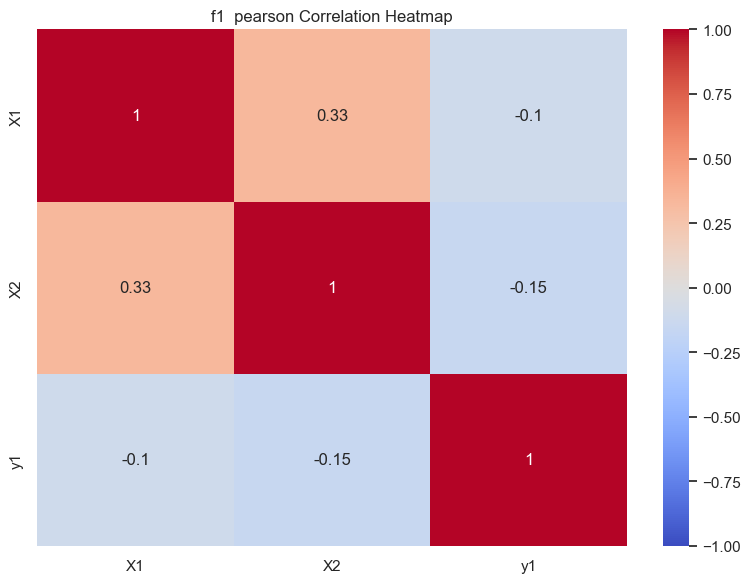


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.532638,0.686870
X2,0.532638,1.000000,0.149915
y1,0.686870,0.149915,1.000000


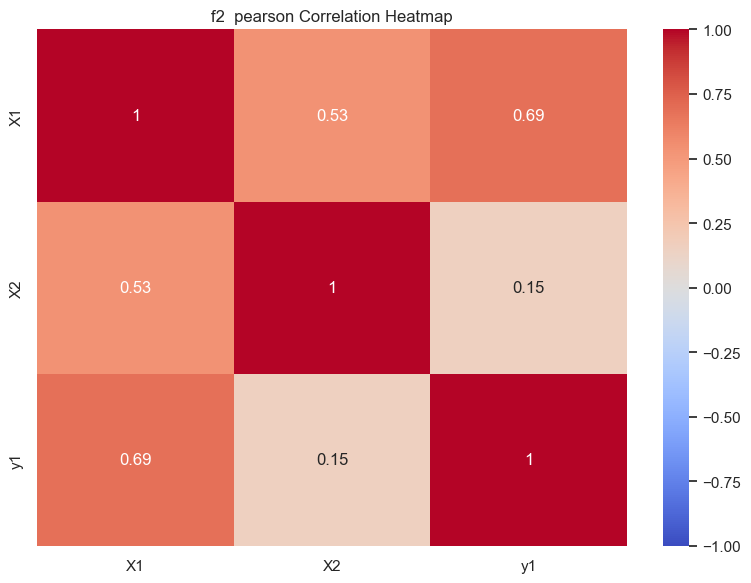


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.392410,-0.134605,0.242307
X2,0.392410,1.000000,-0.320082,0.126037
X3,-0.134605,-0.320082,1.000000,-0.530299
y1,0.242307,0.126037,-0.530299,1.000000


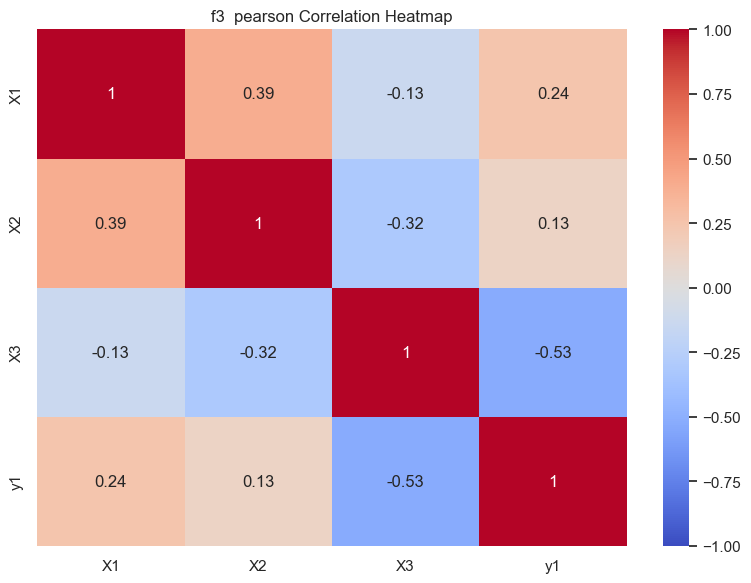


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.254644,0.253147,0.189952,-0.524668
X2,0.254644,1.000000,-0.070617,0.186981,-0.491059
X3,0.253147,-0.070617,1.000000,-0.154109,-0.105642
X4,0.189952,0.186981,-0.154109,1.000000,-0.495805
y1,-0.524668,-0.491059,-0.105642,-0.495805,1.000000


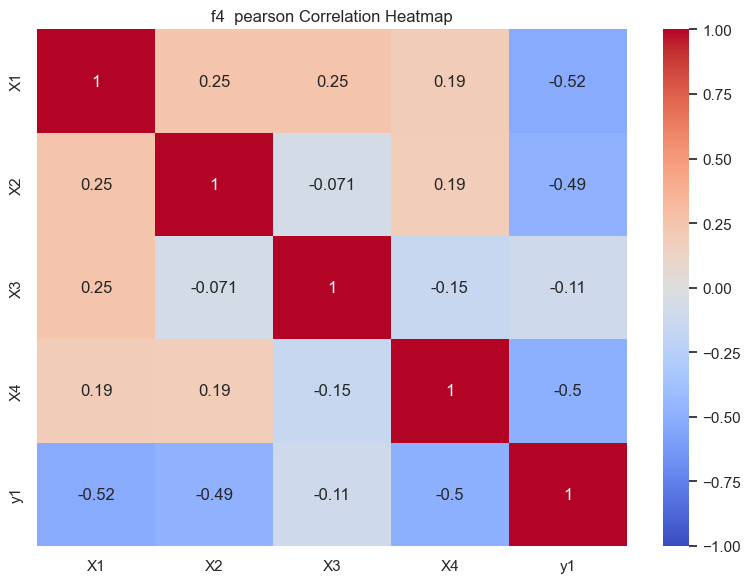


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.317578,-0.297494,0.186466,-0.402019
X2,-0.317578,1.000000,-0.007698,0.090680,0.483279
X3,-0.297494,-0.007698,1.000000,-0.241429,0.455027
X4,0.186466,0.090680,-0.241429,1.000000,0.347076
y1,-0.402019,0.483279,0.455027,0.347076,1.000000


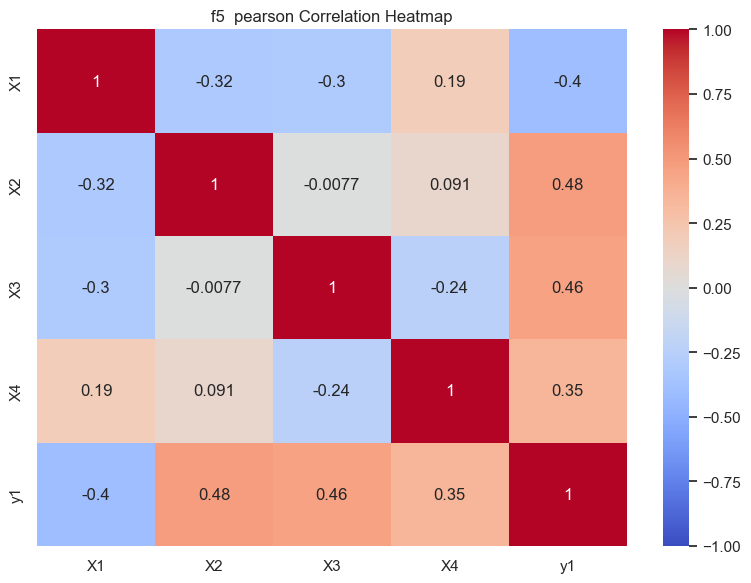


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.204499,-0.086080,0.137039,-0.400991,0.038713
X2,-0.204499,1.000000,0.151255,-0.218702,0.278577,-0.429296
X3,-0.086080,0.151255,1.000000,0.242238,-0.170167,0.341213
X4,0.137039,-0.218702,0.242238,1.000000,-0.245230,0.561140
X5,-0.400991,0.278577,-0.170167,-0.245230,1.000000,-0.608686
y1,0.038713,-0.429296,0.341213,0.561140,-0.608686,1.000000


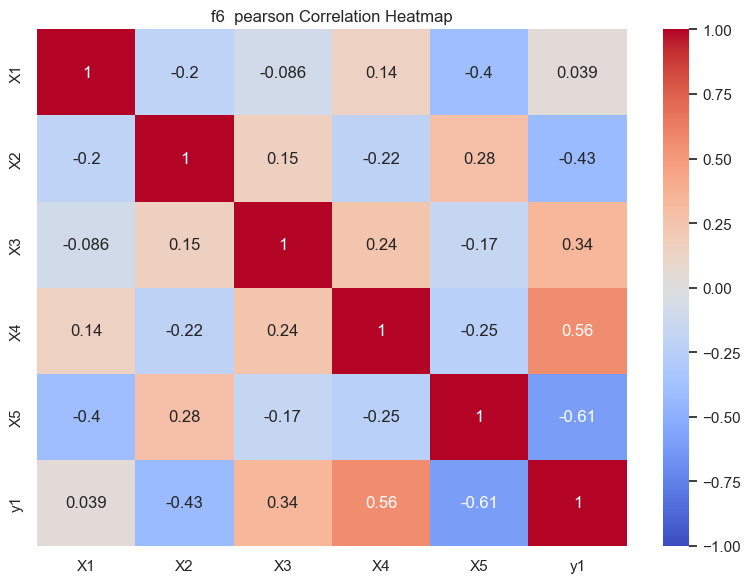


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.016827,-0.160380,-0.185189,-0.020614,-0.451699,-0.355458
X2,-0.016827,1.000000,0.051951,0.093181,0.331633,0.150599,0.002087
X3,-0.160380,0.051951,1.000000,0.165892,-0.263763,0.049117,0.137468
X4,-0.185189,0.093181,0.165892,1.000000,0.047369,0.075846,-0.058378
X5,-0.020614,0.331633,-0.263763,0.047369,1.000000,0.096133,-0.384597
X6,-0.451699,0.150599,0.049117,0.075846,0.096133,1.000000,0.314364
y1,-0.355458,0.002087,0.137468,-0.058378,-0.384597,0.314364,1.000000


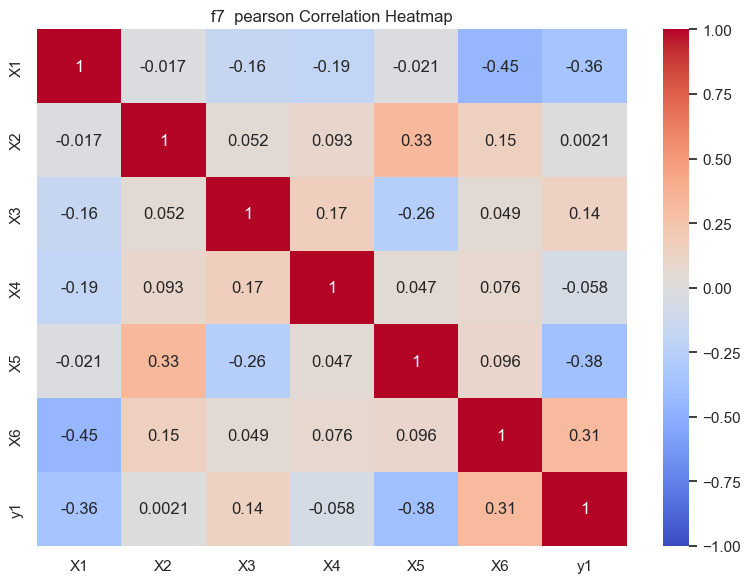


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.129100,0.040182,0.107357,0.277463,0.151058,0.149959,0.130175,-0.630187
X2,0.129100,1.000000,0.060448,-0.219047,0.082596,0.012626,-0.181001,-0.268354,-0.201670
X3,0.040182,0.060448,1.000000,0.031094,-0.041142,-0.210786,-0.204342,0.003726,-0.626334
X4,0.107357,-0.219047,0.031094,1.000000,-0.045946,-0.116035,-0.112668,0.388635,-0.076588
X5,0.277463,0.082596,-0.041142,-0.045946,1.000000,0.091239,0.201878,0.055082,-0.163462
X6,0.151058,0.012626,-0.210786,-0.116035,0.091239,1.000000,-0.020469,0.062232,0.079740
X7,0.149959,-0.181001,-0.204342,-0.112668,0.201878,-0.020469,1.000000,-0.140493,-0.277961
X8,0.130175,-0.268354,0.003726,0.388635,0.055082,0.062232,-0.140493,1.000000,0.055258
y1,-0.630187,-0.201670,-0.626334,-0.076588,-0.163462,0.079740,-0.277961,0.055258,1.000000


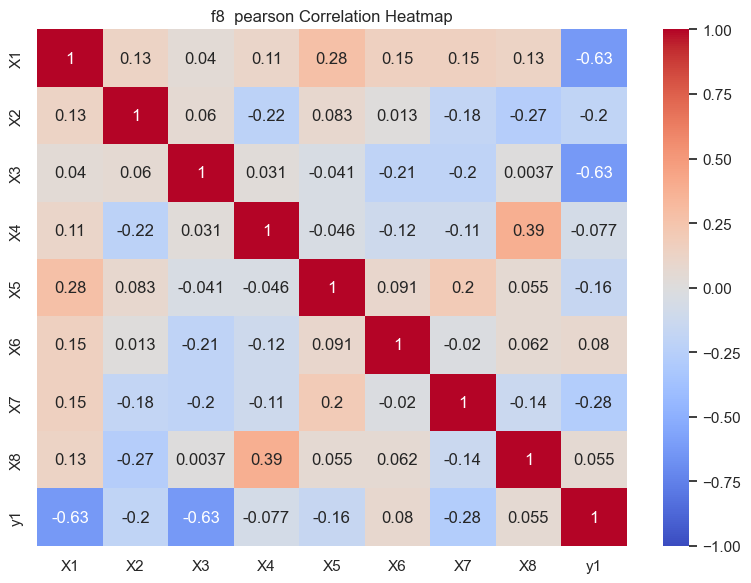

In [9]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

## Pearson Correlation Analysis (f1–f8)

## Observations

- **f1:** X1 and X2 moderately correlated (0.329), y1 weakly negatively correlated with both inputs.  
- **f2:** X1 strongly positively correlated with y1 (0.687) → X1 is likely an important predictor.  
- **f3:** X3 strongly negatively correlated with y1 (-0.530) → decreasing X3 increases y1.  
- **f4:** Multiple moderate negative correlations with y1 → complex relationships.  
- **f5:** X2, X3 moderately positively correlated with y1 → moderate predictors.  
- **f6:** X4 and y1 (0.561), X5 and y1 (-0.609) → strong predictors.  
- **f7:** Most correlations weak, except X1 (-0.356) → moderate predictor.  
- **f8:** X1 (-0.630) → very strong negative effele variables.



f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.136364,0.409091
X2,0.136364,1.000000,0.590909
y1,0.409091,0.590909,1.000000


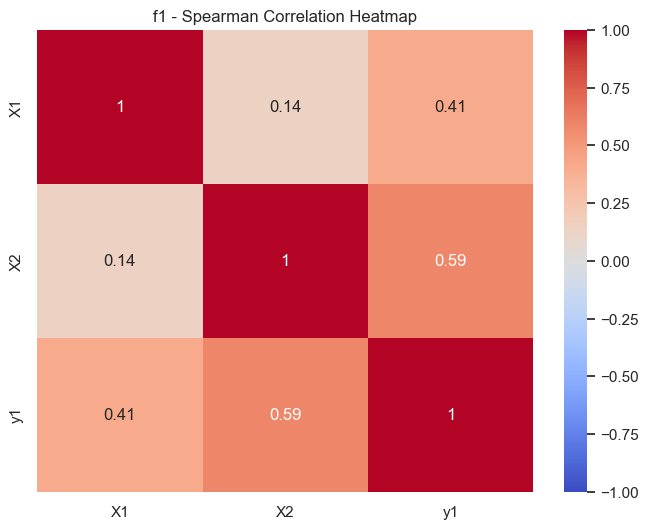


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.536364,0.700000
X2,0.536364,1.000000,0.036364
y1,0.700000,0.036364,1.000000


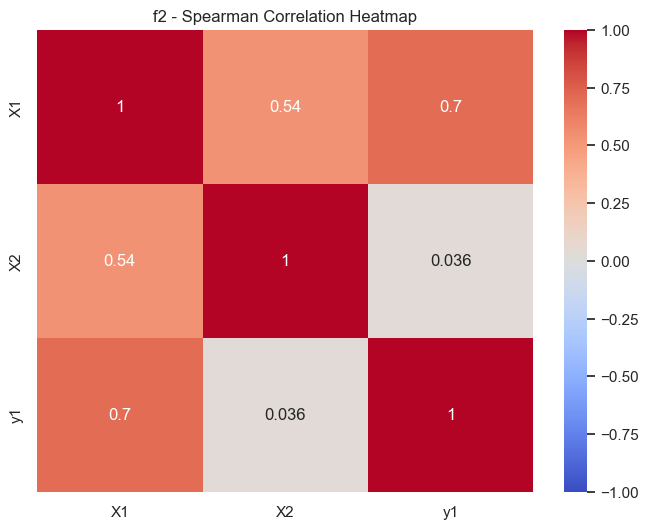


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.397059,-0.252941,0.120588
X2,0.397059,1.000000,-0.308824,0.247059
X3,-0.252941,-0.308824,1.000000,-0.185294
y1,0.120588,0.247059,-0.185294,1.000000


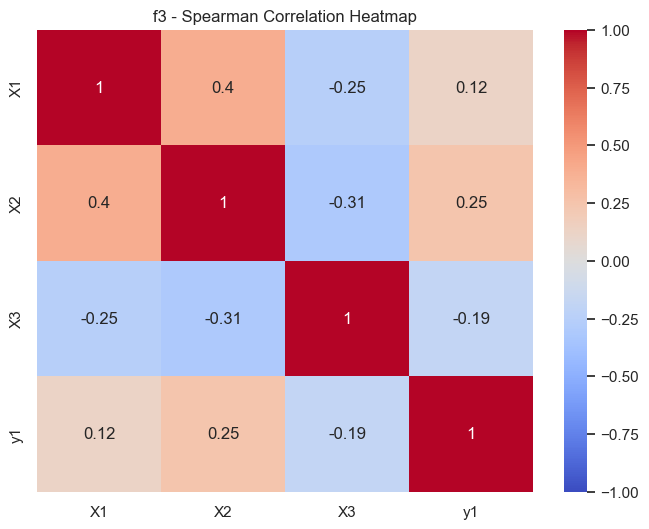


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.253226,0.243145,0.189113,-0.550806
X2,0.253226,1.000000,-0.031452,0.165726,-0.466129
X3,0.243145,-0.031452,1.000000,-0.163710,-0.163306
X4,0.189113,0.165726,-0.163710,1.000000,-0.437097
y1,-0.550806,-0.466129,-0.163306,-0.437097,1.000000


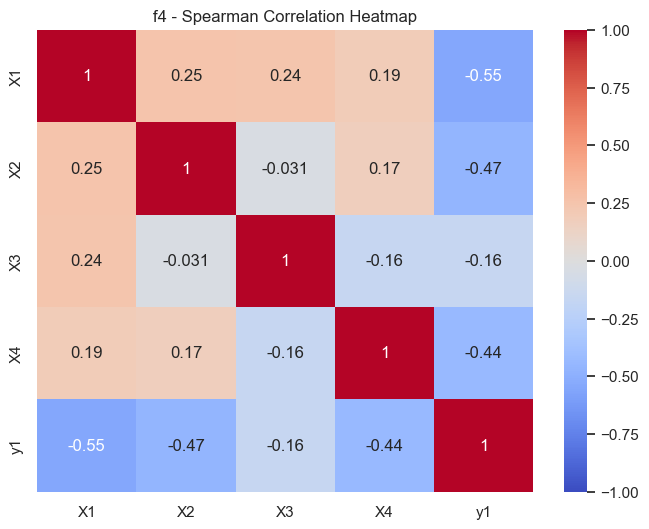


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.351948,-0.274026,0.180519,-0.253247
X2,-0.351948,1.000000,0.089610,0.079221,0.266234
X3,-0.274026,0.089610,1.000000,-0.254545,0.370130
X4,0.180519,0.079221,-0.254545,1.000000,0.385714
y1,-0.253247,0.266234,0.370130,0.385714,1.000000


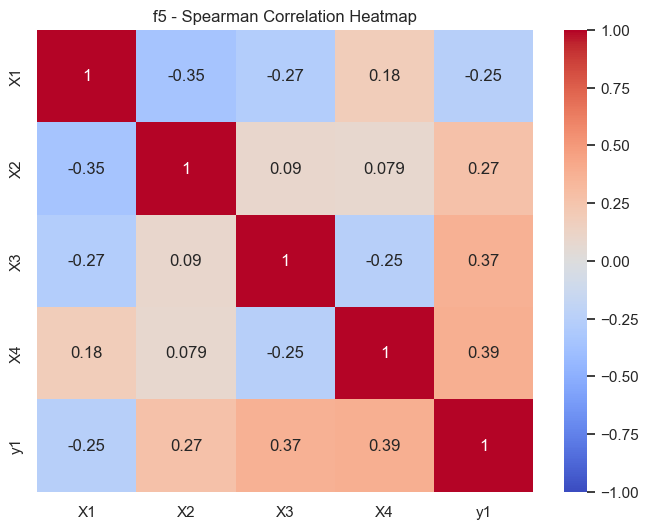


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.162338,-0.048052,0.150649,-0.403896,-0.051948
X2,-0.162338,1.000000,0.077922,-0.157143,0.171429,-0.290909
X3,-0.048052,0.077922,1.000000,0.320779,-0.237662,0.318182
X4,0.150649,-0.157143,0.320779,1.000000,-0.287013,0.583117
X5,-0.403896,0.171429,-0.237662,-0.287013,1.000000,-0.609091
y1,-0.051948,-0.290909,0.318182,0.583117,-0.609091,1.000000


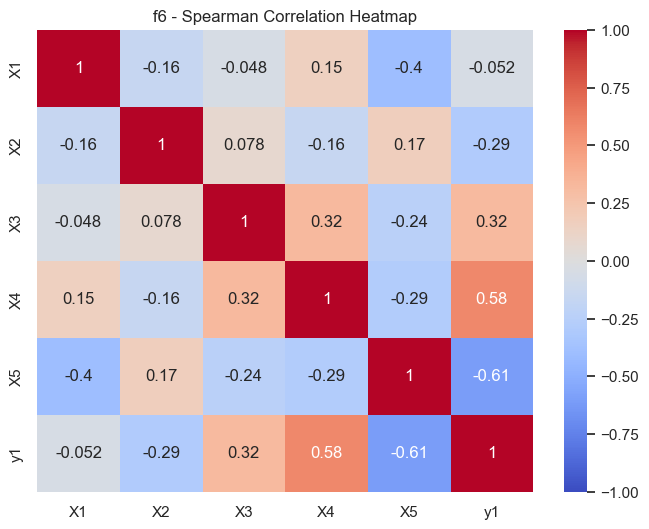


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.092339,-0.145968,-0.184274,-0.054032,-0.407661,-0.301210
X2,-0.092339,1.000000,0.034274,0.127823,0.326210,0.140323,-0.122581
X3,-0.145968,0.034274,1.000000,0.108065,-0.274194,0.090726,0.291935
X4,-0.184274,0.127823,0.108065,1.000000,0.035484,0.120161,-0.069355
X5,-0.054032,0.326210,-0.274194,0.035484,1.000000,0.067742,-0.460081
X6,-0.407661,0.140323,0.090726,0.120161,0.067742,1.000000,0.179032
y1,-0.301210,-0.122581,0.291935,-0.069355,-0.460081,0.179032,1.000000


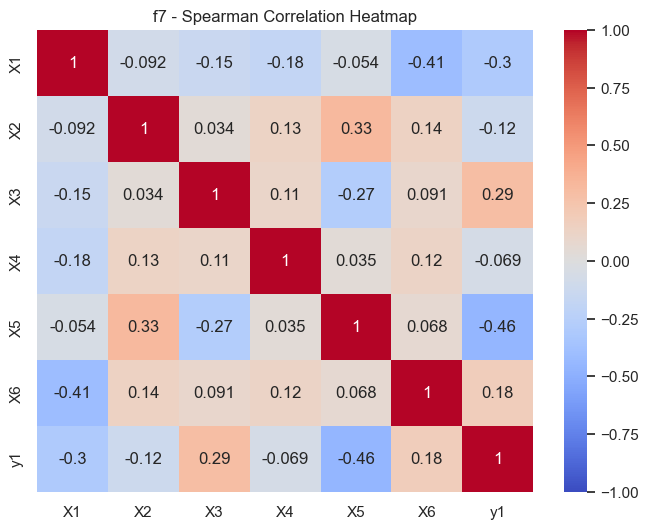


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.129965,-0.000174,0.102439,0.287108,0.172997,0.155401,0.126132,-0.614111
X2,0.129965,1.000000,0.054181,-0.220035,0.060801,0.010279,-0.165854,-0.275261,-0.204530
X3,-0.000174,0.054181,1.000000,0.044599,-0.035366,-0.166028,-0.196864,-0.036063,-0.579791
X4,0.102439,-0.220035,0.044599,1.000000,-0.072125,-0.133101,-0.091289,0.370209,-0.108362
X5,0.287108,0.060801,-0.035366,-0.072125,1.000000,0.128397,0.211672,0.018990,-0.115331
X6,0.172997,0.010279,-0.166028,-0.133101,0.128397,1.000000,0.003484,0.109059,0.014983
X7,0.155401,-0.165854,-0.196864,-0.091289,0.211672,0.003484,1.000000,-0.119861,-0.289024
X8,0.126132,-0.275261,-0.036063,0.370209,0.018990,0.109059,-0.119861,1.000000,0.042683
y1,-0.614111,-0.204530,-0.579791,-0.108362,-0.115331,0.014983,-0.289024,0.042683,1.000000


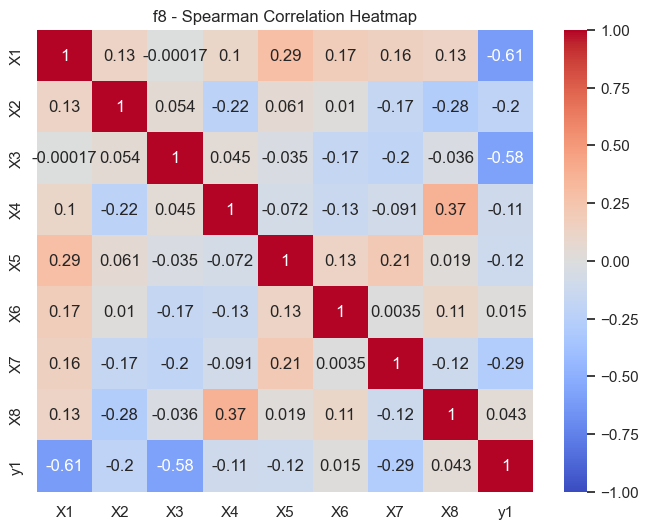

In [10]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

## Spearman Correlation Analysis (f1–f8)

### Observations

- **f1:** `X2` strongly positively correlated with `y1` (0.591), `X1` moderately correlated (0.409) → monotonic increasing trends despite weak Pearson linear correlation.  
- **f2:** `X1` strongly positively correlated with `y1` (0.700) → very strong monotonic predictor, `X2` nearly uncorrelated with `y1` (0.036).  
- **f3:** Correlations mostly weak (`X1` 0.121, `X2` 0.247, `X3` -0.185) → monotonic relationships are weak.  
- **f4:** `X1` negatively correlated with `y1` (-0.551), `X2` (-0.466), `X4` (-0.437) → moderate-to-strong negative monotonic trends.  
- **f5:** `X3` and `y1` (0.370), `X4` and `y1` (0.386) → moderate monotonic predictors.  
- **f6:** `X4` (0.583) and `X5` (-0.609) → strong monotonic predictors; other variables weaker.  
- **f7:** Most correlations weak; `X1` and `y1` (-0.301) → moderate negative monotonic trend.  
- **f8:** `X1` (-0.614), `X3` (-0.580) → strong negative monotonic trends; other inpin small datasets.



f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.018182,0.272727
X2,0.018182,1.000000,0.454545
y1,0.272727,0.454545,1.000000


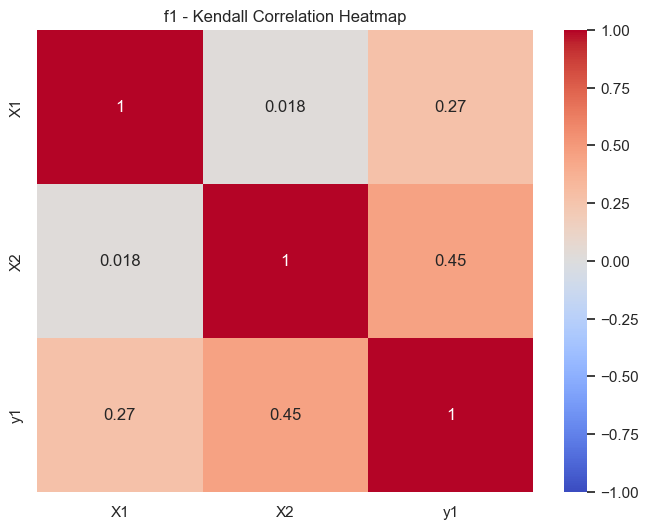


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.345455,0.527273
X2,0.345455,1.000000,0.090909
y1,0.527273,0.090909,1.000000


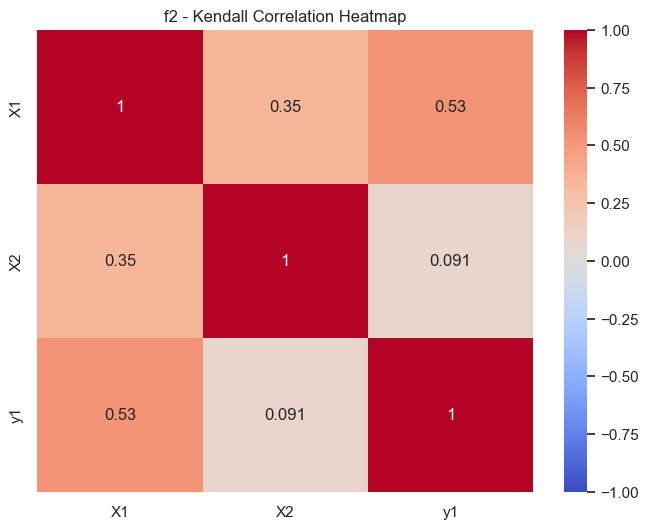


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.283333,-0.183333,0.100000
X2,0.283333,1.000000,-0.233333,0.183333
X3,-0.183333,-0.233333,1.000000,-0.116667
y1,0.100000,0.183333,-0.116667,1.000000


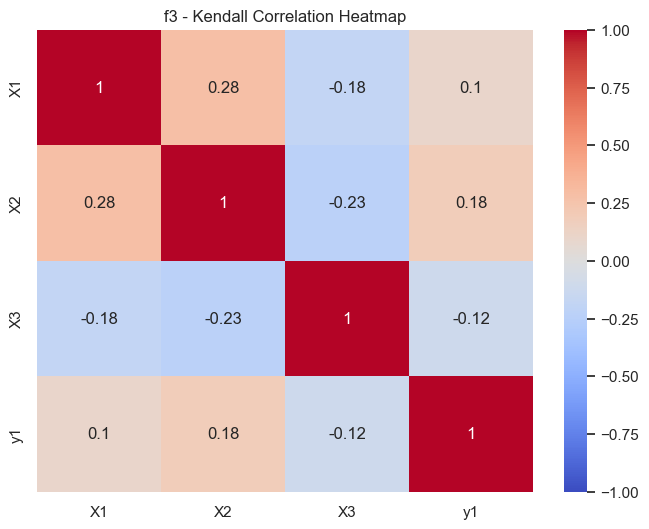


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.187097,0.182796,0.144086,-0.384946
X2,0.187097,1.000000,-0.019355,0.113978,-0.337634
X3,0.182796,-0.019355,1.000000,-0.122581,-0.152688
X4,0.144086,0.113978,-0.122581,1.000000,-0.311828
y1,-0.384946,-0.337634,-0.152688,-0.311828,1.000000


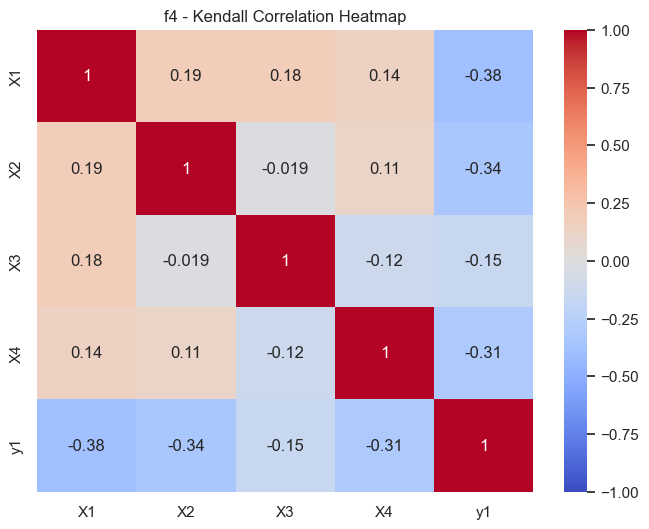


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.257143,-0.209524,0.133333,-0.209524
X2,-0.257143,1.000000,0.038095,0.038095,0.152381
X3,-0.209524,0.038095,1.000000,-0.200000,0.276190
X4,0.133333,0.038095,-0.200000,1.000000,0.276190
y1,-0.209524,0.152381,0.276190,0.276190,1.000000


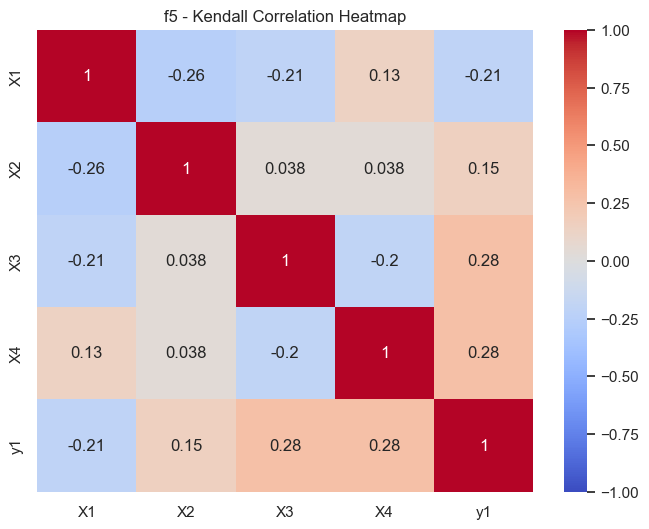


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.133333,-0.038095,0.123810,-0.304762,-0.028571
X2,-0.133333,1.000000,0.085714,-0.114286,0.104762,-0.209524
X3,-0.038095,0.085714,1.000000,0.228571,-0.123810,0.228571
X4,0.123810,-0.114286,0.228571,1.000000,-0.247619,0.409524
X5,-0.304762,0.104762,-0.123810,-0.247619,1.000000,-0.419048
y1,-0.028571,-0.209524,0.228571,0.409524,-0.419048,1.000000


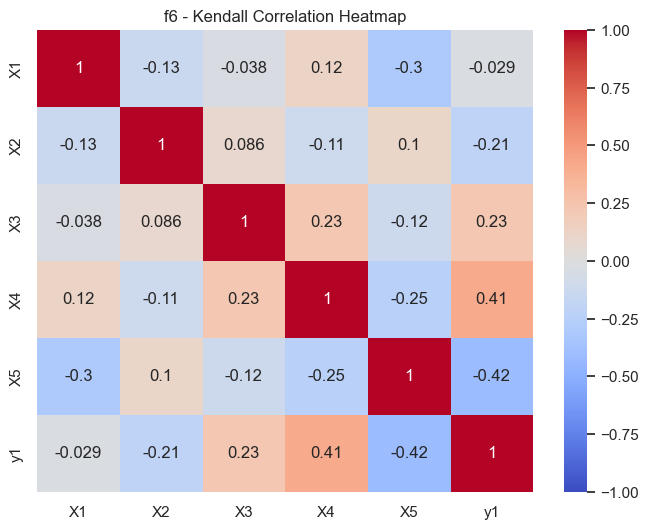


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.032258,-0.105376,-0.135484,-0.075269,-0.264516,-0.264516
X2,-0.032258,1.000000,0.015054,0.088172,0.225806,0.079570,-0.101075
X3,-0.105376,0.015054,1.000000,0.049462,-0.174194,0.075269,0.195699
X4,-0.135484,0.088172,0.049462,1.000000,0.019355,0.053763,-0.058065
X5,-0.075269,0.225806,-0.174194,0.019355,1.000000,0.070968,-0.316129
X6,-0.264516,0.079570,0.075269,0.053763,0.070968,1.000000,0.122581
y1,-0.264516,-0.101075,0.195699,-0.058065,-0.316129,0.122581,1.000000


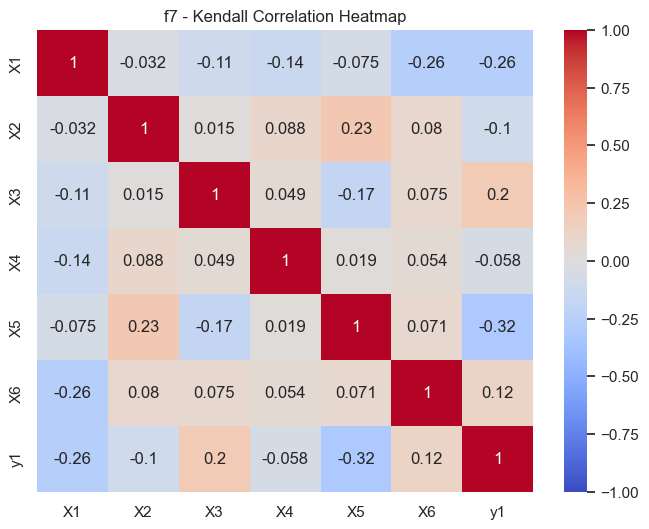


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.097561,-0.031707,0.056098,0.192683,0.097561,0.087805,0.080488,-0.441463
X2,0.097561,1.000000,0.036585,-0.168293,0.051220,-0.019512,-0.131707,-0.173171,-0.129268
X3,-0.031707,0.036585,1.000000,0.009756,-0.019512,-0.109756,-0.119512,-0.029268,-0.414634
X4,0.056098,-0.168293,0.009756,1.000000,-0.048780,-0.060976,-0.060976,0.268293,-0.073171
X5,0.192683,0.051220,-0.019512,-0.048780,1.000000,0.090244,0.143902,0.019512,-0.068293
X6,0.097561,-0.019512,-0.109756,-0.060976,0.090244,1.000000,0.004878,0.065854,-0.002439
X7,0.087805,-0.131707,-0.119512,-0.060976,0.143902,0.004878,1.000000,-0.080488,-0.226829
X8,0.080488,-0.173171,-0.029268,0.268293,0.019512,0.065854,-0.080488,1.000000,0.039024
y1,-0.441463,-0.129268,-0.414634,-0.073171,-0.068293,-0.002439,-0.226829,0.039024,1.000000


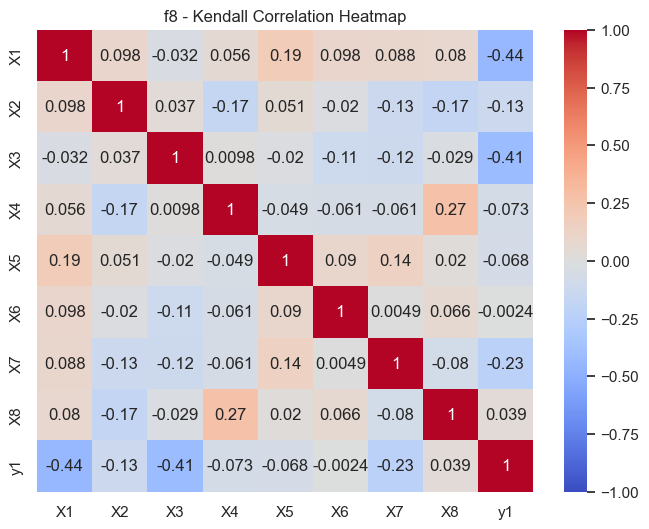

In [11]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


### Kendall Correlation Analysis

#### Observations

- **f1:** `X2` moderately positively correlated with `y1` (0.455), `X1` weaker (0.273) → monotonic increasing trend.  
- **f2:** `X1` moderately positively correlated with `y1` (0.527), `X2` weak (0.091) → X1 likely the main predictor.  
- **f3:** Weak correlations overall (`X1` 0.100, `X2` 0.183, `X3` -0.117) → monotonic relationships are weak.  
- **f4:** `X1` (-0.385), `X2` (-0.338), `X4` (-0.312) → moderate negative monotonic trends.  
- **f5:** `X3` and `X4` both 0.276 → moderate positive monotonic relationships.  
- **f6:** `X4` (0.410), `X5` (-0.419) → strong monotonic predictors; others weaker.  
- **f7:** `X1` (-0.265), `X5` (-0.316) → moderate negative monotonic trends; most others weak.  
- **f8:** `X1` (-0.441), `X3` (-0.415) → strongest negative monotonic trends; ot relationships.  


In [12]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n{name} — Mutual Information with Output")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



f1 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,4.440892e-16
1,X2,0.000000e+00



f2 — Mutual Information with Output


,Feature,Mutual_Info
0,X1,0.253860
1,X2,0.003211



f3 — Mutual Information with Output


...

,Feature,Mutual_Info
4,X5,0.136400
3,X4,0.129899
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



f7 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.179169
0,X1,0.108791
5,X6,0.071990
3,X4,0.050969
2,X3,0.017253
1,X2,0.000000



f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.259240
0,X1,0.247021
6,X7,0.069723
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


## Mutual Information Regression Analysis

### Observations

- **f1:** X1 (4.44e-16), X2 (0) → features provide almost no information about y1  
- **f2:** X1 (0.254), X2 (0.003) → X1 is clearly informative  
- **f3:** X3 (0.175) → only X3 contributes significant information  
- **f4:** X1 (0.297), X4 (0.274), X2 (0.164), X3 (0.113) → multiple informative features; complex relationships  
- **f5:** X4 (0.179), X2 (0.050), X1 (0.022), X3 (0) → X4 most informative; others moderate or negligible  
- **f6:** X5 (0.136), X4 (0.130) → X5 and X4 are the strongest predictors  
- **f7:** X5 (0.179), X1 (0.109), X6 (0.072), X4 (0.051), X3 (0.017), X2 (0) → X5 most important; several moderate contributors  
- **f8:** X3 (0.259), X1 (0.247), X7 (0.070), others ≈ 0 → X3 and X1 are the strongestr or non-monotonic


In [13]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n{name} — Partial Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



f1 — Partial Correlation
          n         r          CI95%     p-val
pearson  11 -0.055621  [-0.66, 0.59]  0.878705
          n         r         CI95%     p-val
pearson  11 -0.126797  [-0.7, 0.55]  0.727048

f2 — Partial Correlation
          n         r         CI95%     p-val
pearson  11  0.725425  [0.18, 0.93]  0.017574
          n         r         CI95%     p-val
pearson  11 -0.351059  [-0.8, 0.36]  0.319908

f3 — Partial Correlation
          n         r          CI95%     p-val
pearson  16  0.241372  [-0.33, 0.68]  0.405788
          n         r          CI95%     p-val
pearson  16 -0.143182  [-0.63, 0.42]  0.625324
          n         r          CI95%    p-val
pearson  16 -0.531166  [-0.83, -0.0]  0.05064

f4 — Partial Correlation
          n         r           CI95%     p-val
pearson  31 -0.416117  [-0.68, -0.05]  0.027631
          n         r           CI95%     p-val
pearson  31 -0.432588  [-0.69, -0.07]  0.021497
          n         r          CI95%     p-val
pearson

## Partial Correlation Analysis

### Observatios

- **f1:** r-values ≈ 0, p > 0.7 → X1, X2 have **no significant direct effect** on y1  
- **f2:** X1 r = 0.725, p = 0.018 → X1 is a **strong direct predictor**; X2 non-significant  
- **f3:** X3 r = -0.531, p = 0.051 → moderate negative effect; borderline significance  
- **f4:** Multiple r-values negative (-0.416 to -0.476), p < 0.05 → several features **directly negatively influence** y1  
- **f5:** X2, X3, X4 r = 0.516–0.633, p < 0.05 → multiple **strong direct predictors**  
- **f6:** X4 r = 0.517 (p = 0.033), X5 r = -0.620 (p = 0.008) → strong direct predictors; X1–X3 weaker  
- **f7:** Only X6 r = -0.452, p = 0.020 → X6 moderately significant; others weak or non-significant  
- **f8:** Multiple strong negative correlations: X1 r = -0.833, X3 r = -0.892, X7 r = -0.722 → highly significant; X2, X4–X
6### Takeaways


- Partial correlation isolates **direct effects**, removing confounding from other variables  
- Some functions (f2, f5, f6, f8) have **strong direct predictors**; others (f1, f7) show weak or non-significant direct effects  
- Large r-values with significant p-values → features are **key drivers of y1**  
- Non-significant r-values → apparent correlation may be due to **other variables** or noise  
- Useful for **multivariate feature selection** in regression modelsy be due to **ot**



Feature vs Output Plots for f1
X shape for f1: (11, 2)
y shape for f1: (11,)


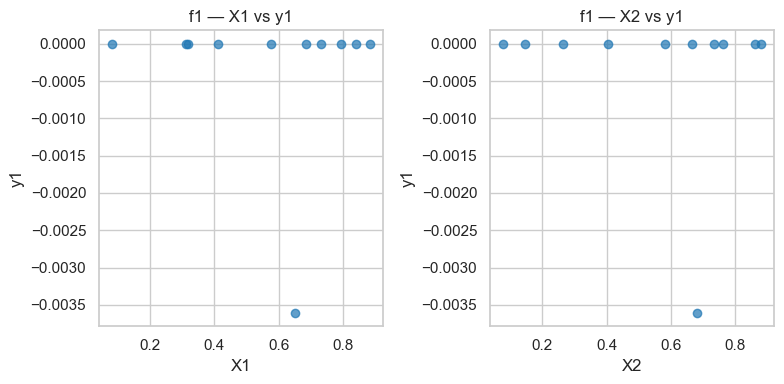


Feature vs Output Plots for f2
X shape for f2: (11, 2)
y shape for f2: (11,)


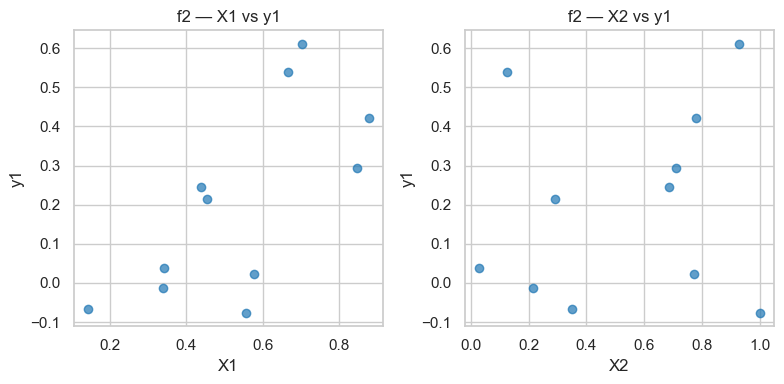


Feature vs Output Plots for f3
X shape for f3: (16, 3)
y shape for f3: (16,)


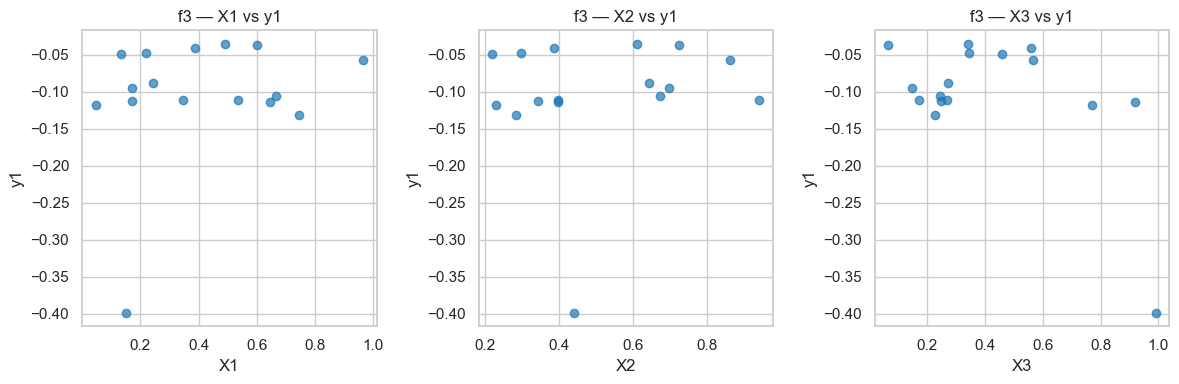


Feature vs Output Plots for f4
X shape for f4: (31, 4)
y shape for f4: (31,)


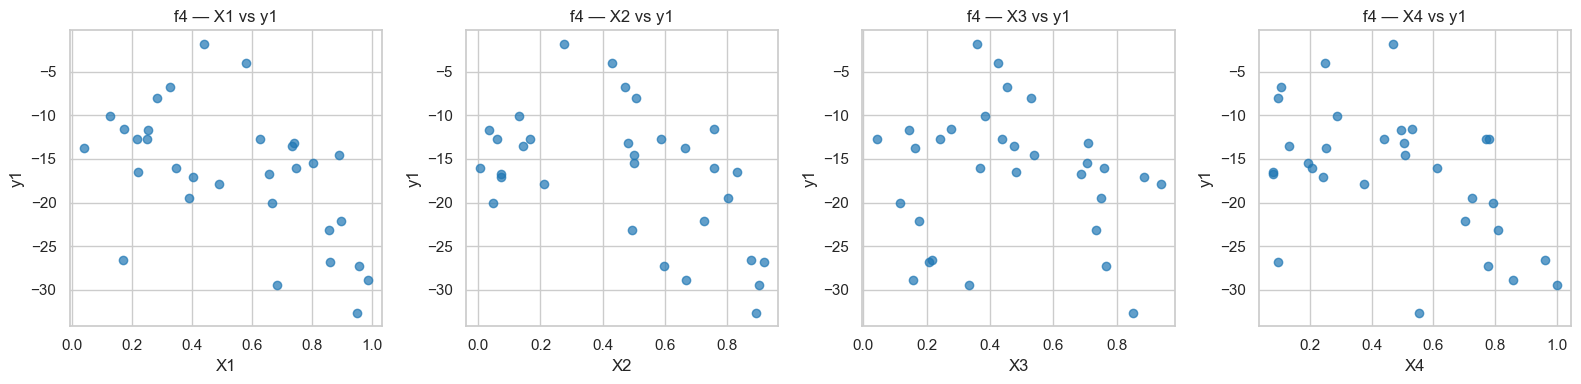


Feature vs Output Plots for f5
X shape for f5: (21, 4)
y shape for f5: (21,)


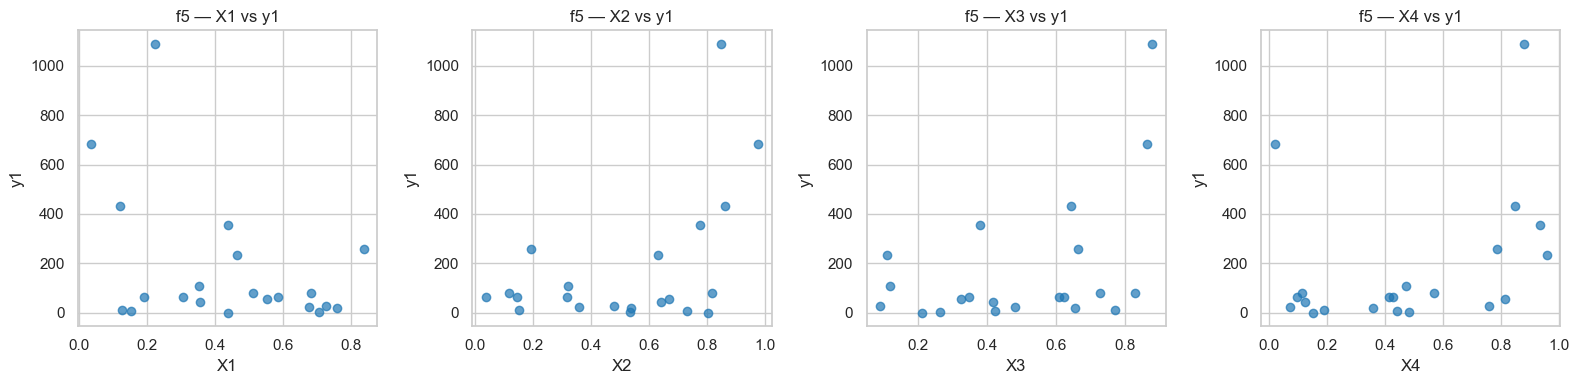


Feature vs Output Plots for f6
X shape for f6: (21, 5)
y shape for f6: (21,)


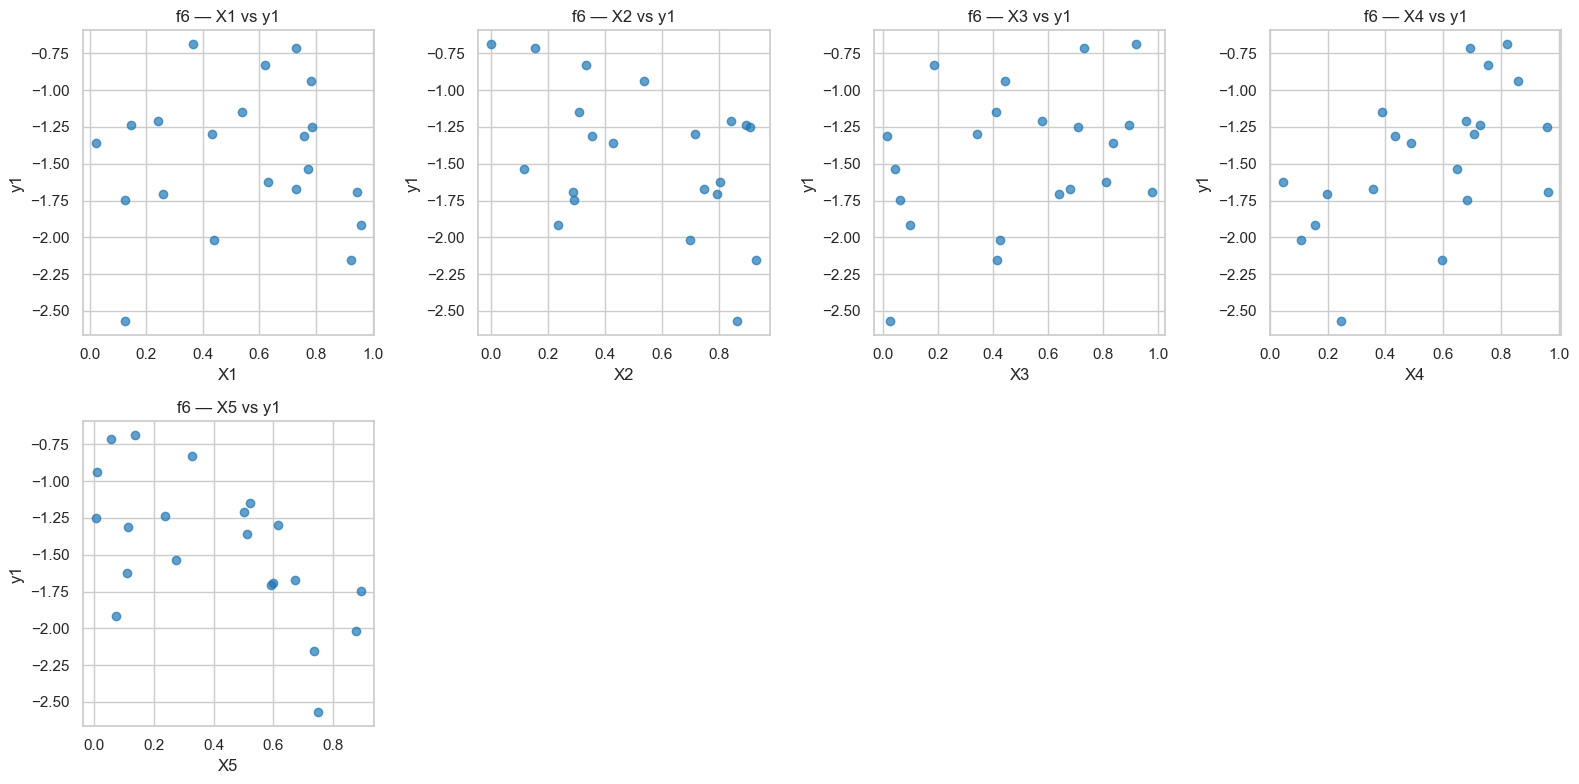


Feature vs Output Plots for f7
X shape for f7: (31, 6)
y shape for f7: (31,)


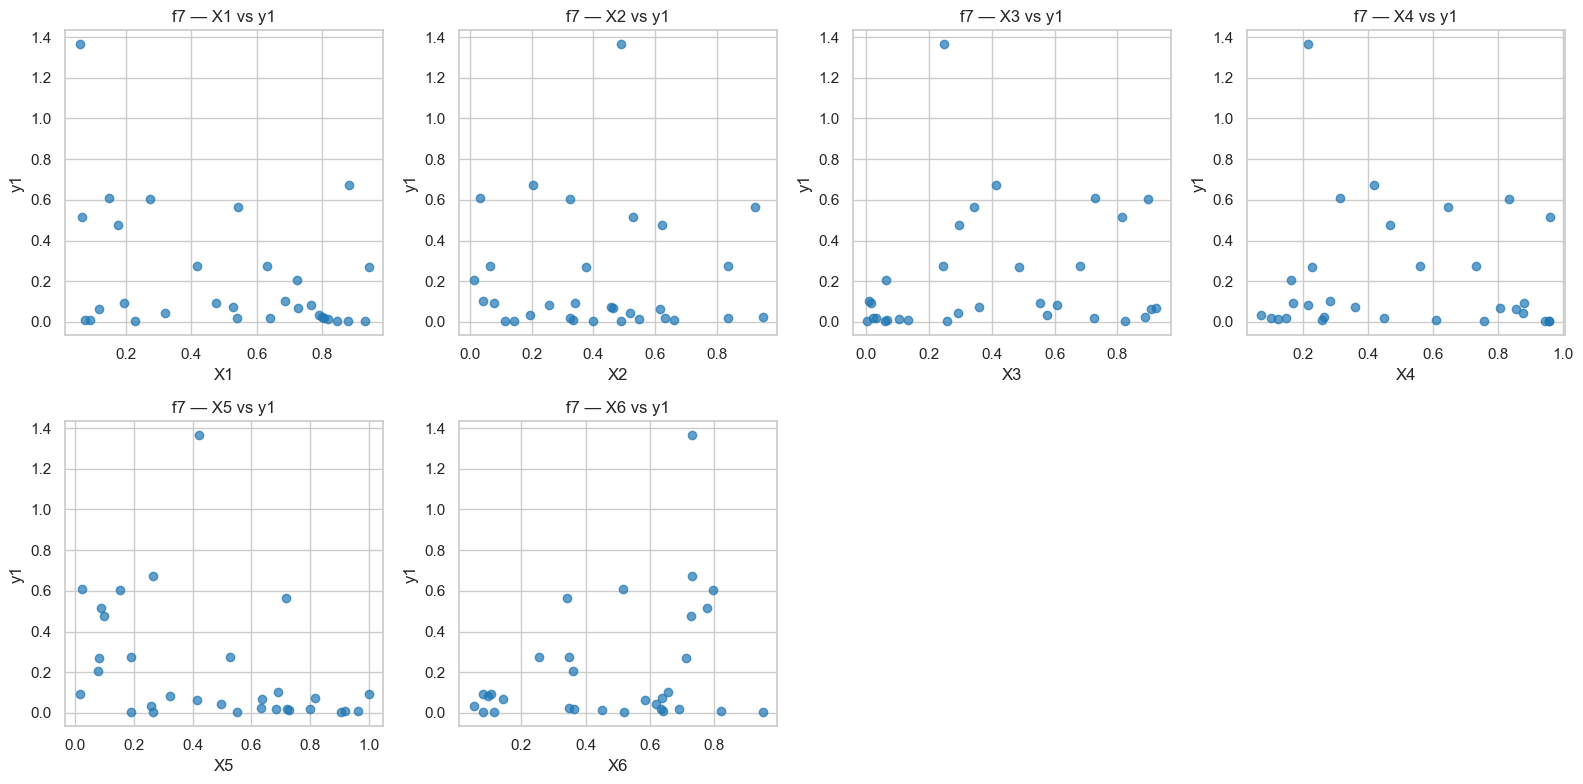


Feature vs Output Plots for f8
X shape for f8: (41, 8)
y shape for f8: (41,)


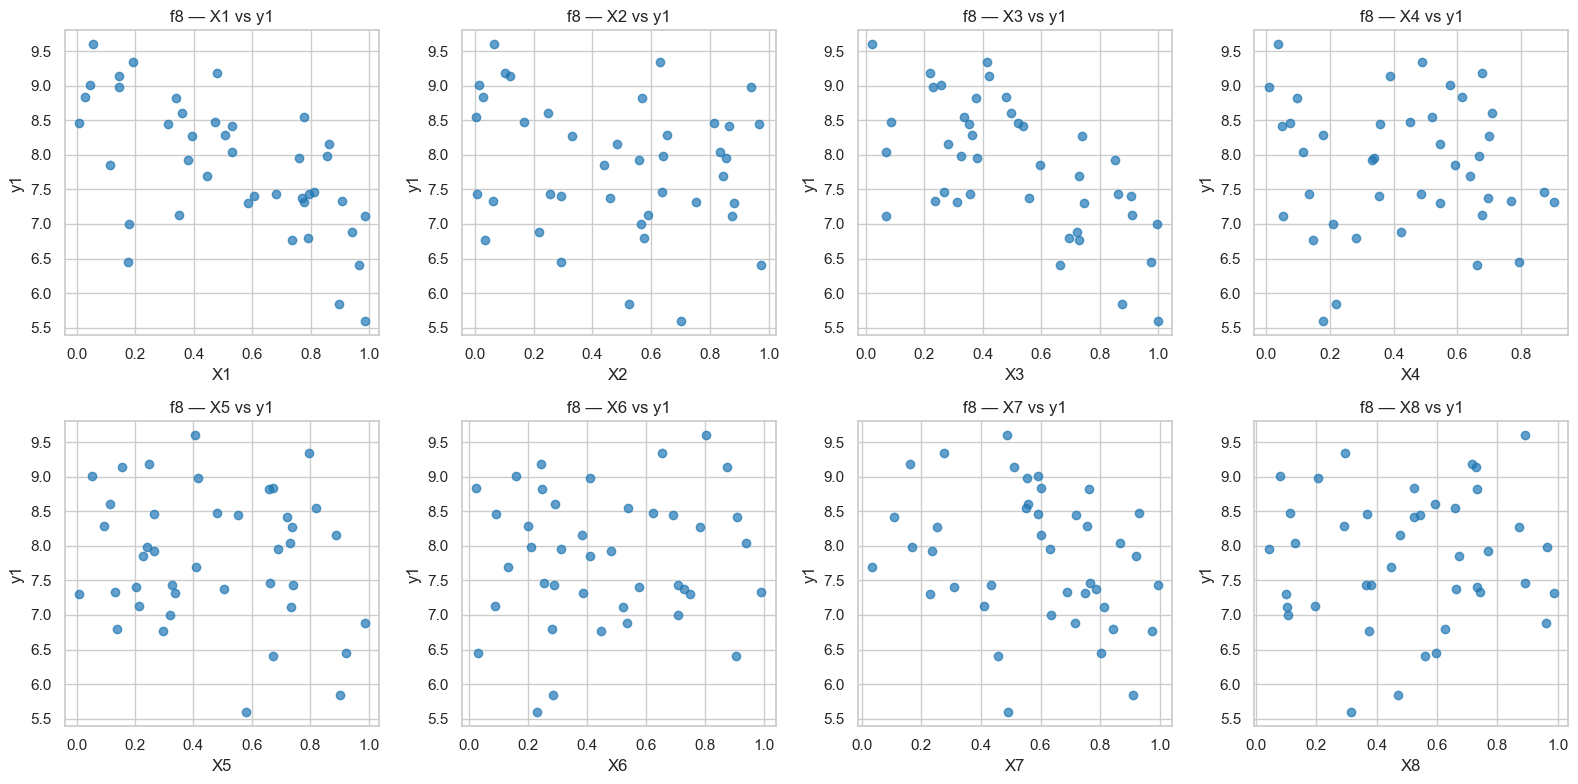

In [14]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")


    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot


    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



f1 — Feature & Output Distributions


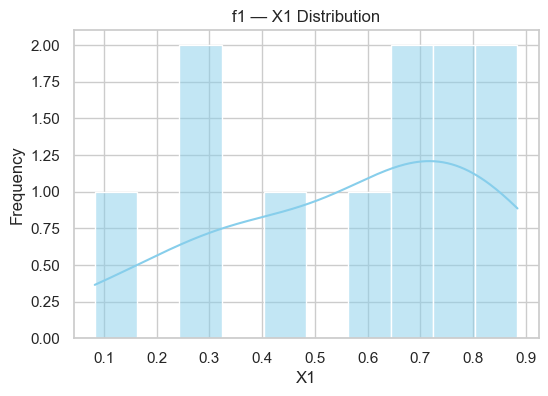

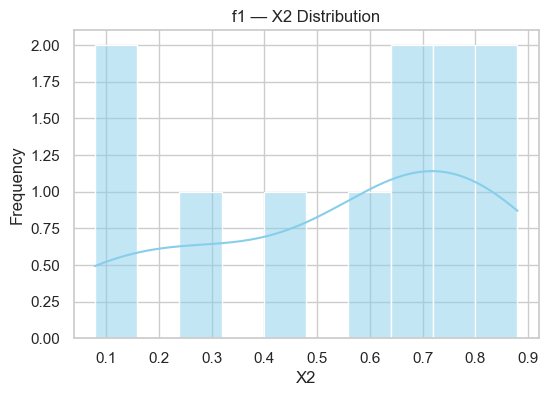

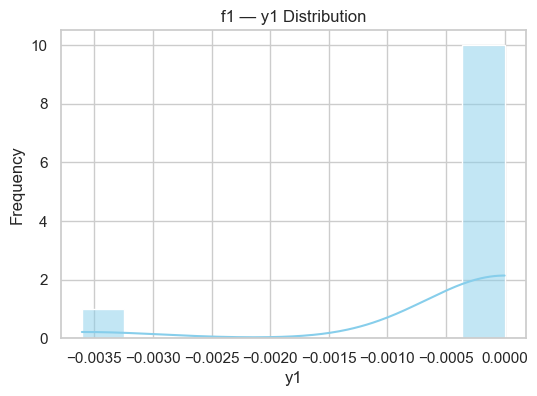


f2 — Feature & Output Distributions


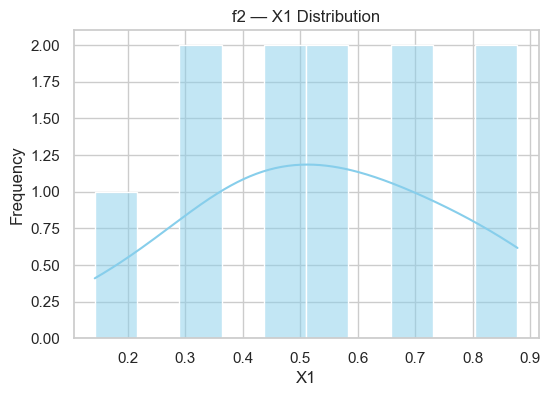

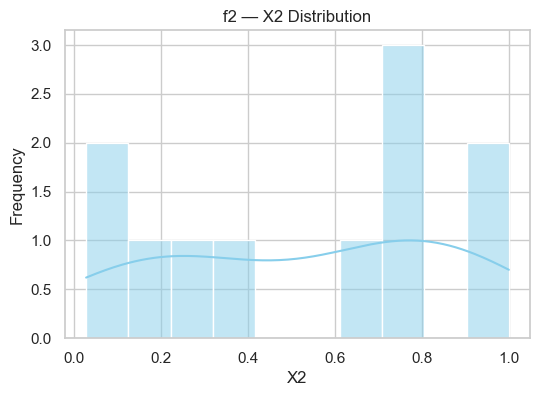

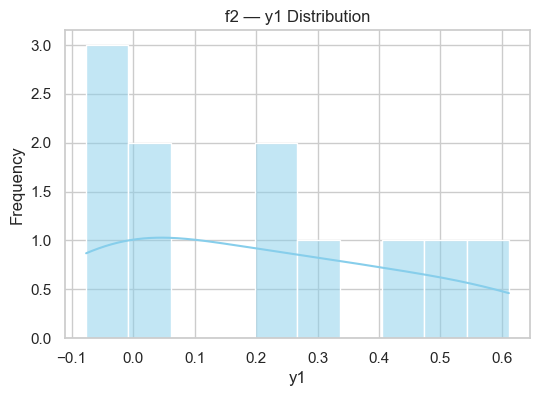


f3 — Feature & Output Distributions


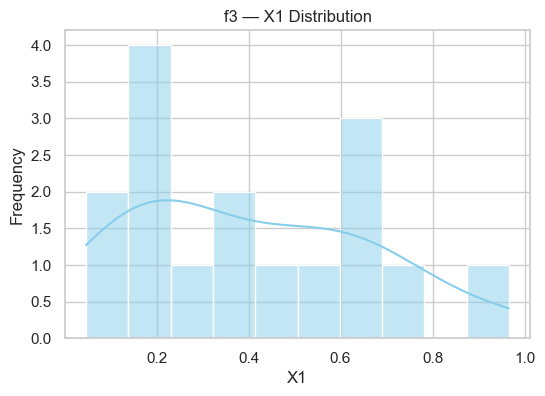

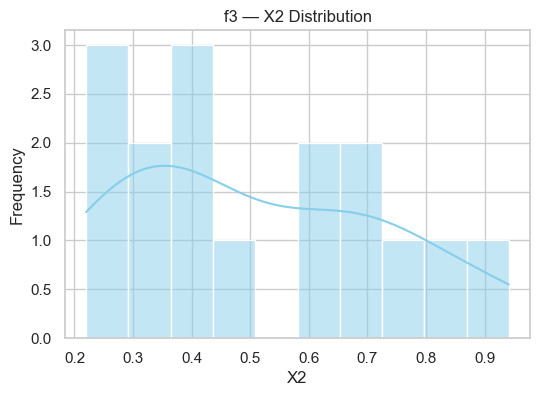

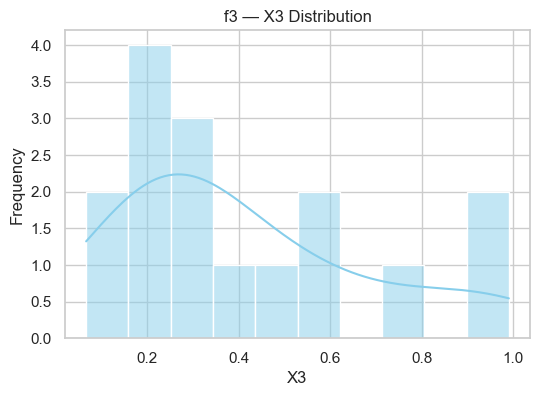

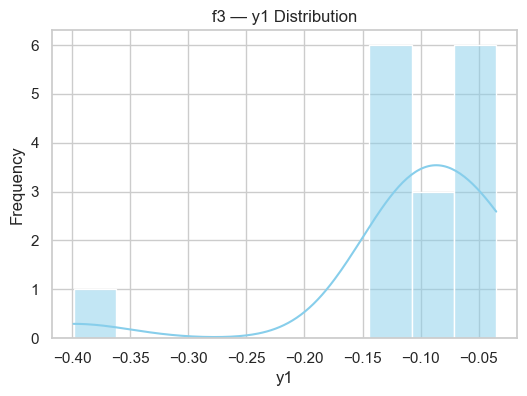


f4 — Feature & Output Distributions


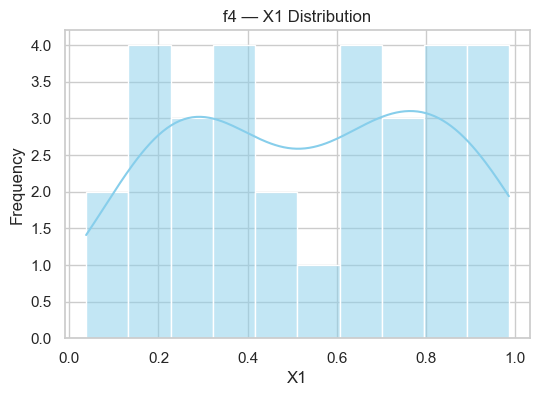

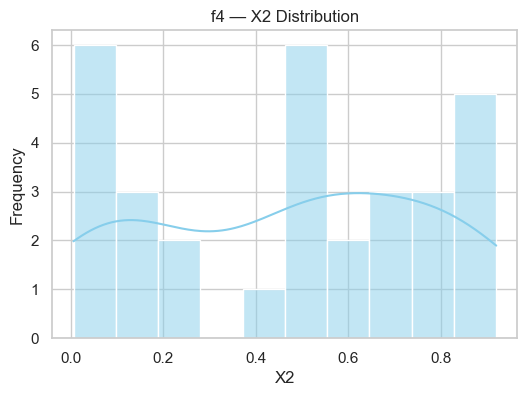

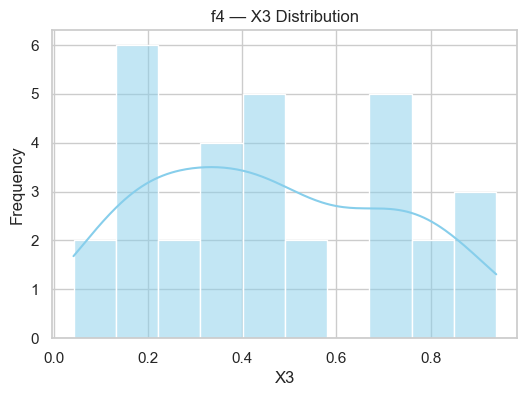

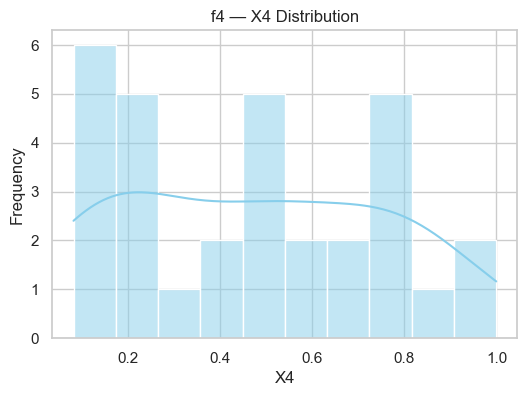

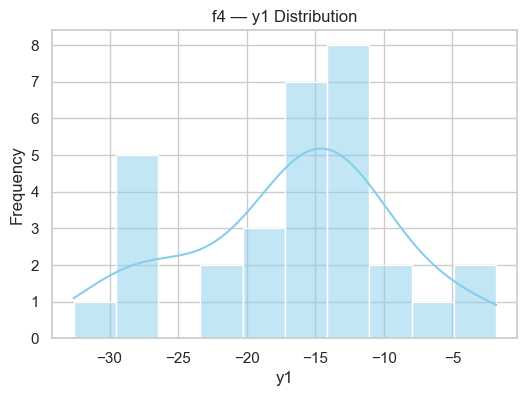


f5 — Feature & Output Distributions


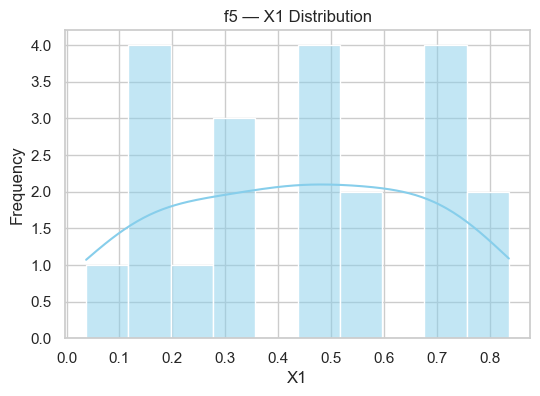

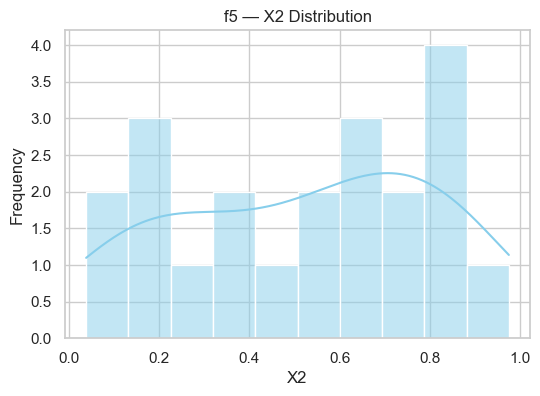

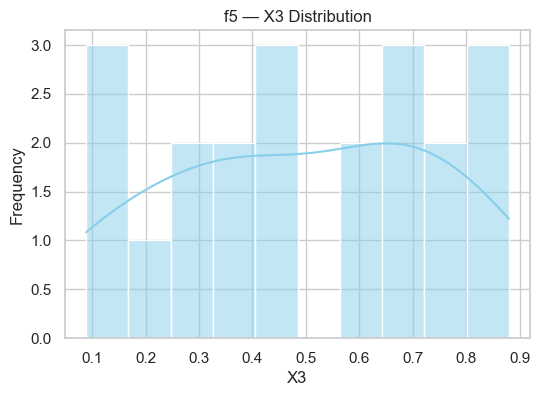

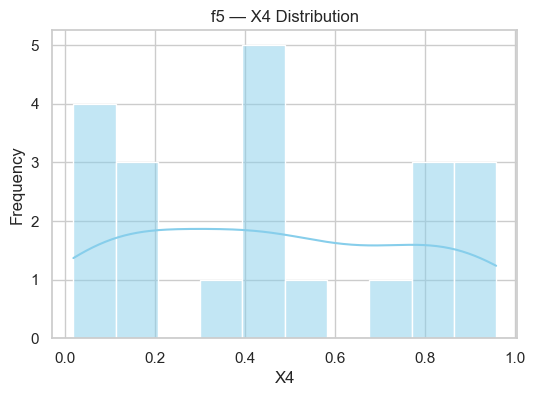

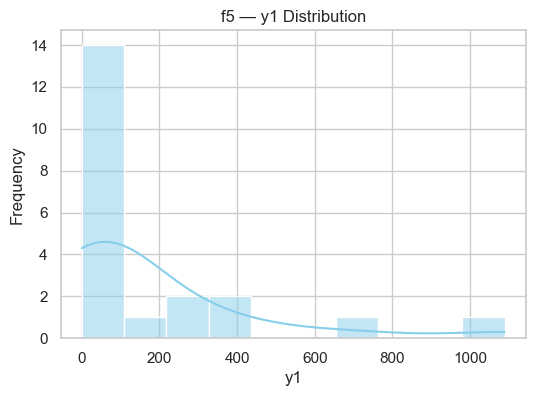


f6 — Feature & Output Distributions


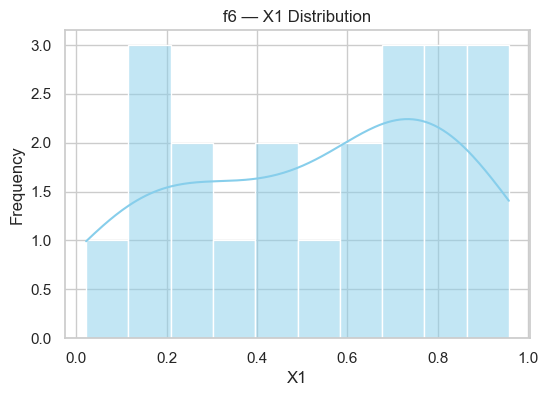

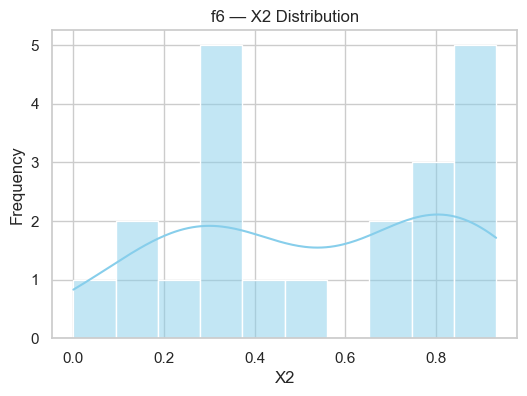

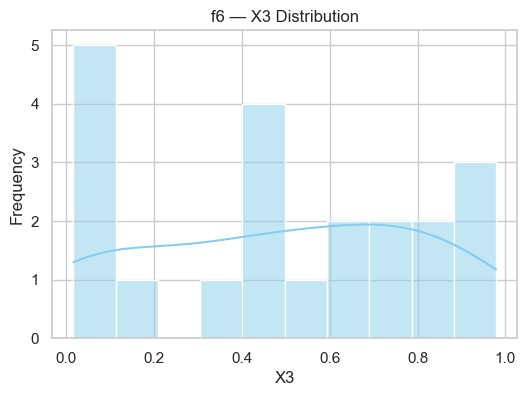

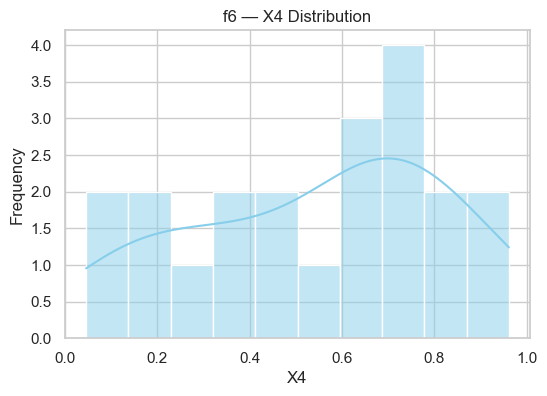

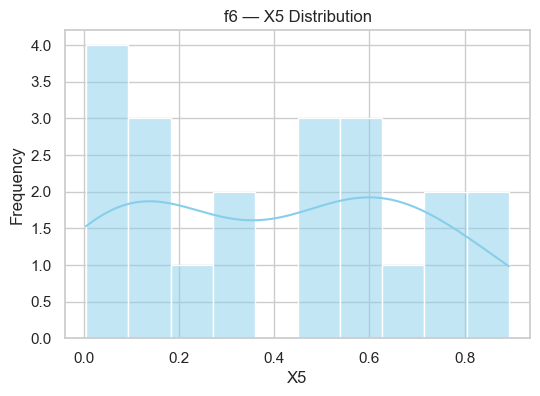

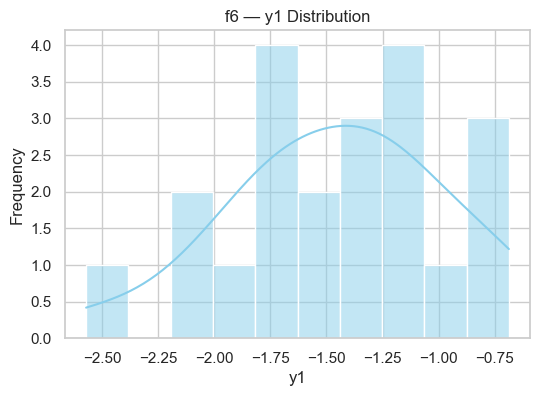


f7 — Feature & Output Distributions


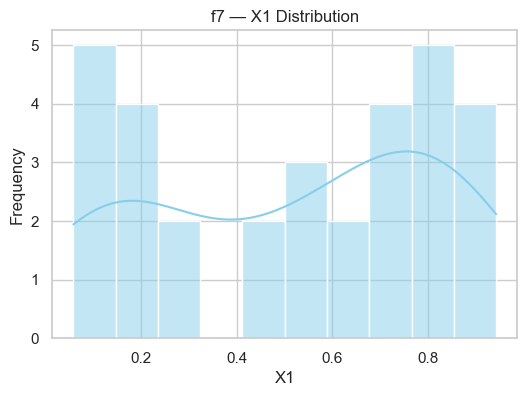

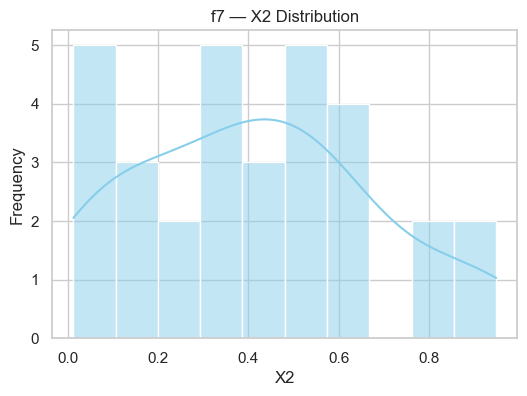

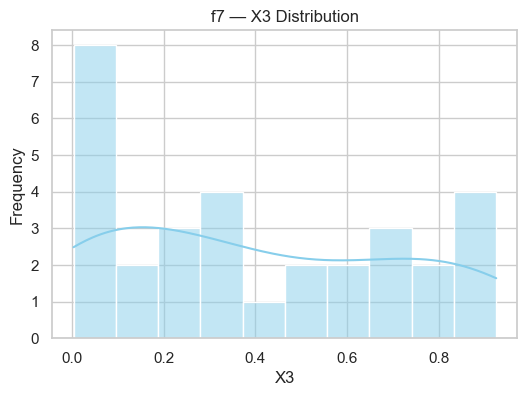

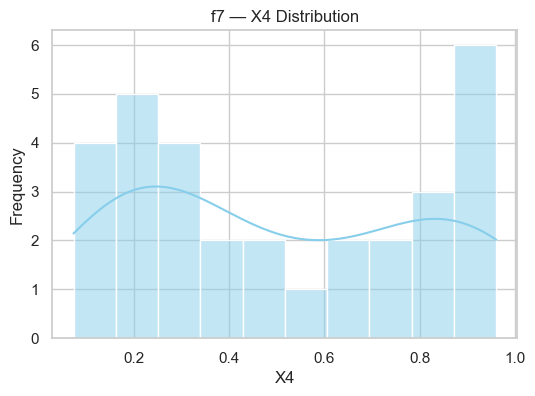

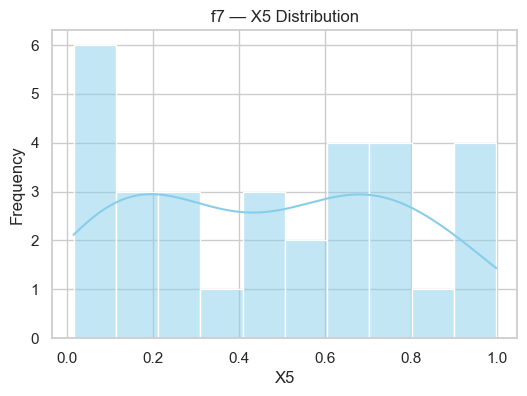

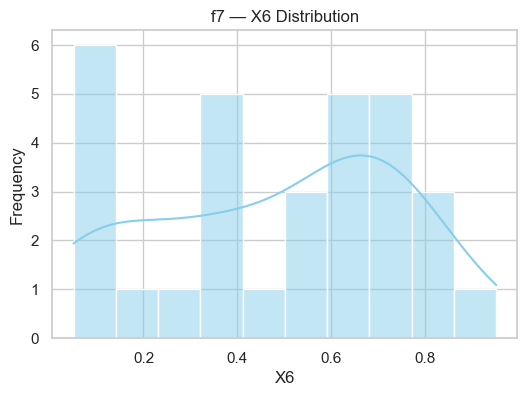

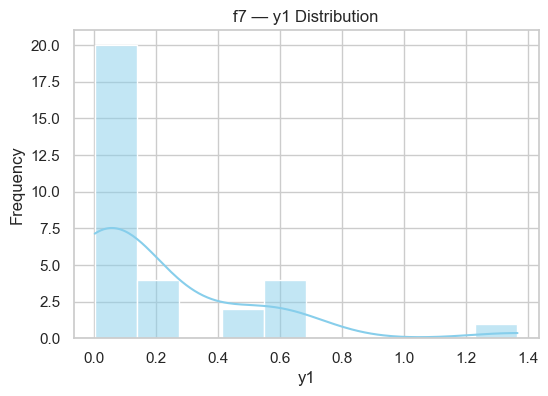


f8 — Feature & Output Distributions


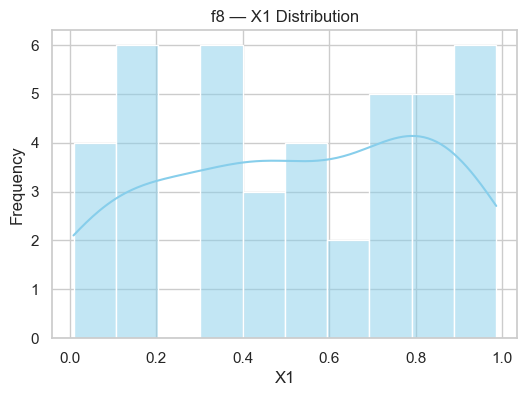

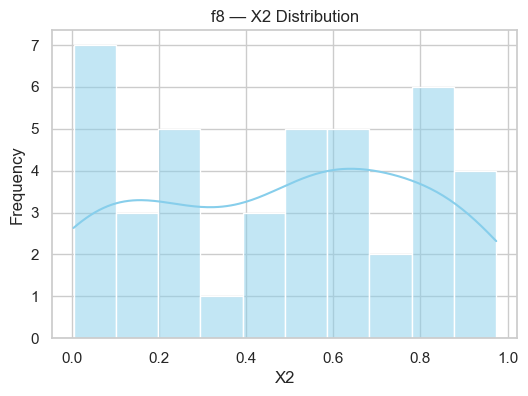

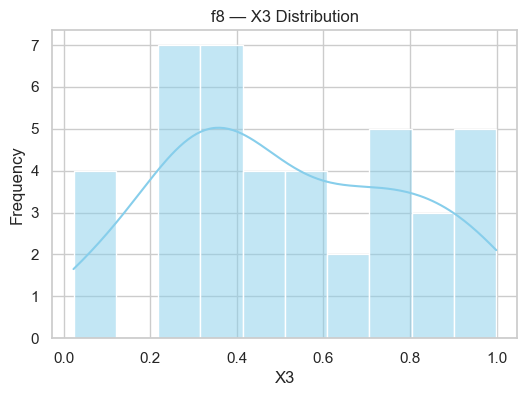

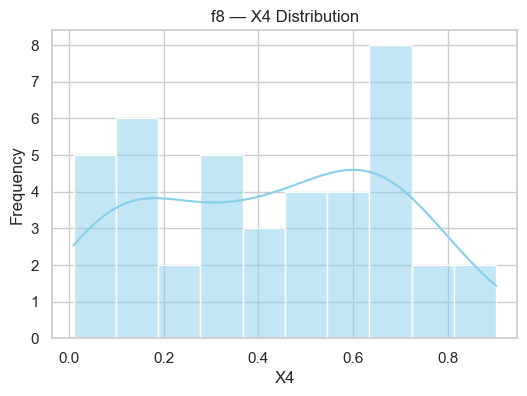

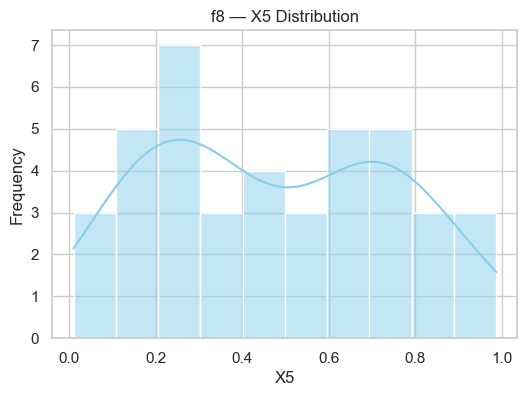

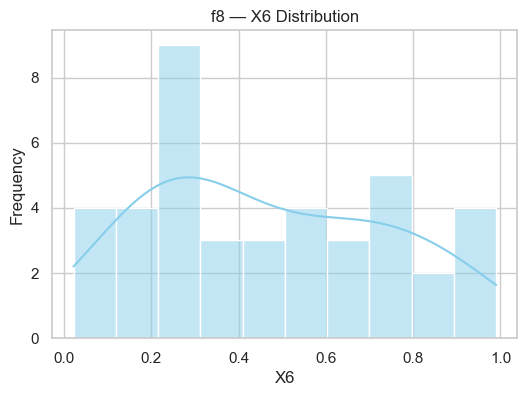

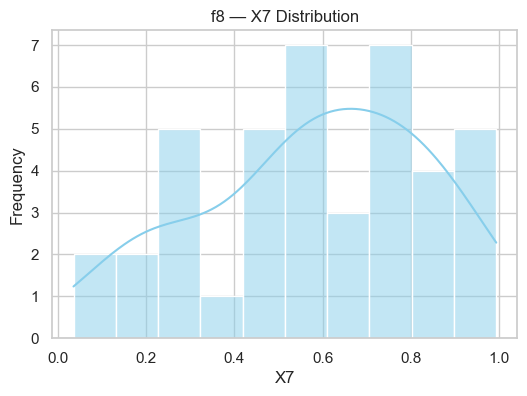

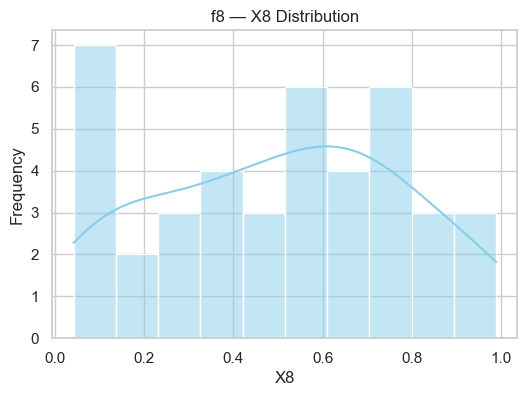

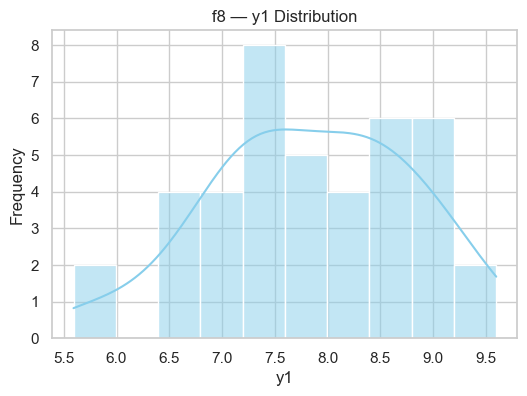

In [15]:
for name, df in functions_data.items():
    print(f"\n{name} — Feature & Output Distributions")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### ML Modelling


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from itertools import product


#### Load Data for f1

In [17]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


#### Define search space and candidate grid (exploration-focused) 

In [18]:
# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))


#### Define UCB acquisition function

In [19]:
def ucb_acquisition(mu, sigma, beta):
    """
    Upper Confidence Bound acquisition function.

    Parameters
    ----------
    mu : ndarray
        Posterior mean predictions
    sigma : ndarray
        Posterior standard deviation predictions
    beta : float
        Exploration weight

    Returns
    -------
    ndarray
        UCB values
    """
    return mu + beta * sigma


#### Hyperparameter grid (explicitly exploration-oriented)

In [20]:
# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


#### Grid search over GP + UCB hyperparameters

In [21]:
results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })


#### Convert results to DataFrame

In [22]:
results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df


,beta,lengthscale,ucb_value,X1,X2
19,5.0,0.50,0.021402,0.810547,0.000276
15,3.0,0.50,0.020976,0.810547,0.000276
11,2.0,0.50,0.020762,0.810547,0.000276
7,1.0,0.50,0.020549,0.810547,0.000276
3,0.5,0.50,0.020443,0.810547,0.000276
18,5.0,0.20,0.006136,0.992302,0.797845
17,5.0,0.10,0.005345,0.857886,0.816513
16,5.0,0.05,0.004930,0.810298,0.784712
14,3.0,0.20,0.004582,0.961810,0.777435
10,2.0,0.20,0.003888,0.943634,0.776439


#### Visualise hyperparameter effects

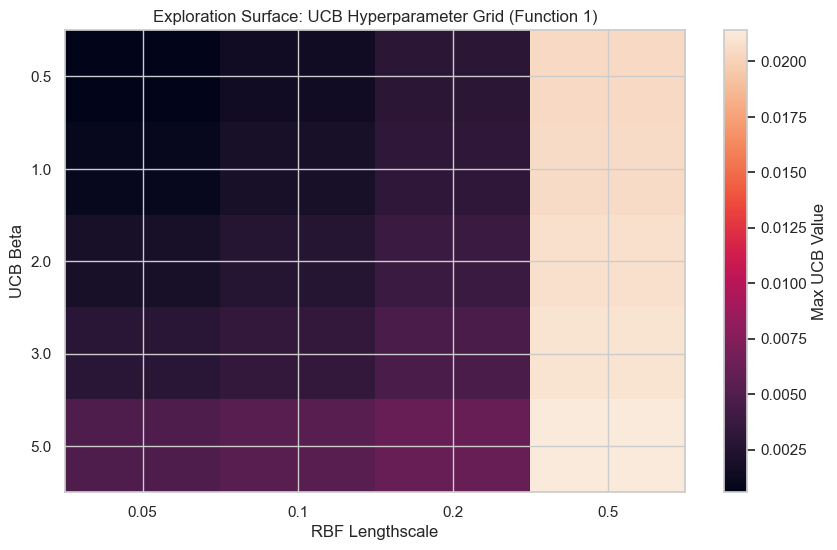

In [23]:
pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 1)")
plt.show()


In [24]:
best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimised):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")


Best hyperparameter configuration (Exploration-Optimised):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.8105
X2: 0.0003
UCB value: 0.0214


#### f2 

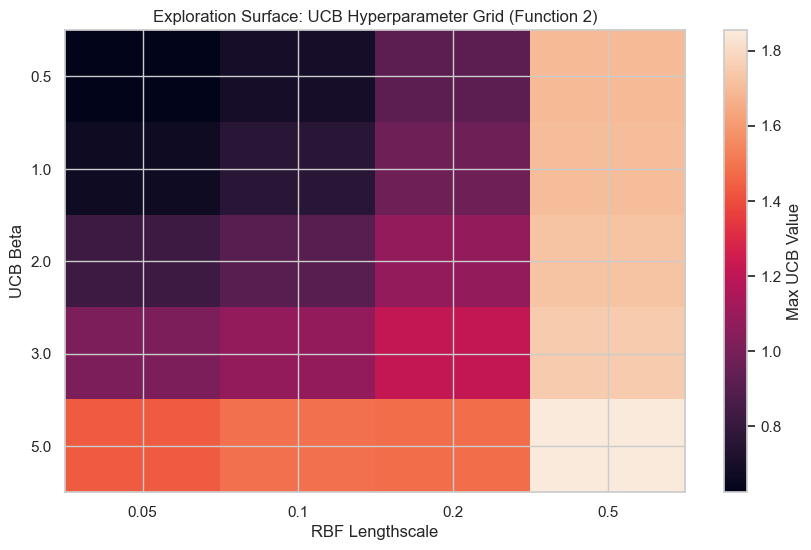

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.9993
X2: 0.0704
UCB value: 1.8543


In [25]:
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):

    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 2)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

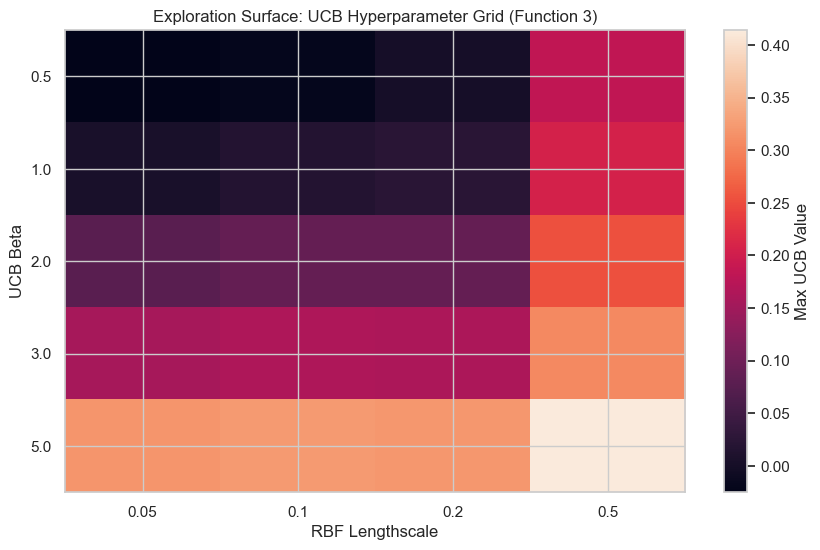

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.9870
X2: 0.0206
X3: 0.7307
UCB value: 0.4141


In [26]:
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):

    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 3)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

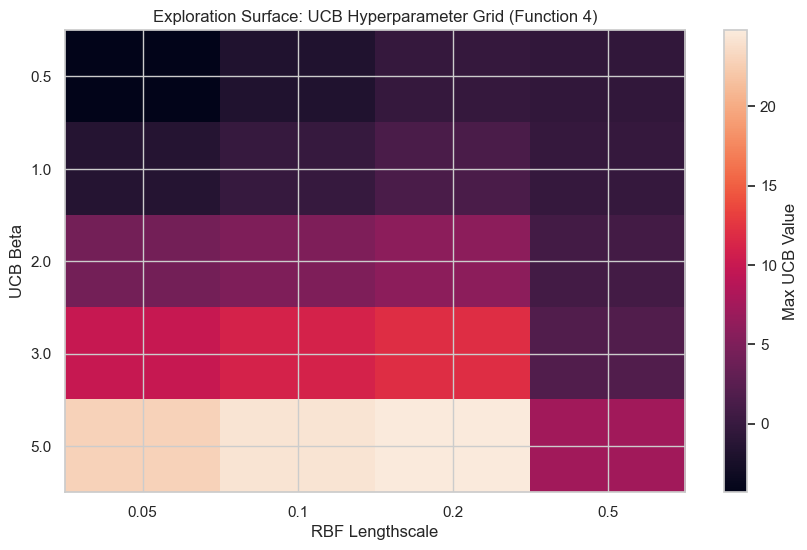

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.2
Proposed next query:
X1: 0.2868
X2: 0.4624
X3: 0.4755
X4: 0.4178
UCB value: 24.7960


In [27]:
# Extract existing data for Function 1
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):

    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 4)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

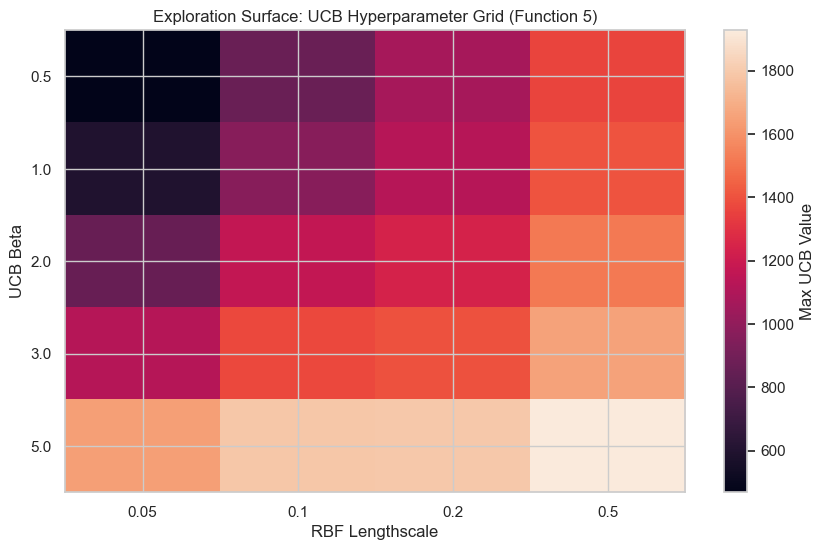

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.5767
X2: 0.9625
X3: 0.9404
X4: 0.9142
UCB value: 1928.0134


In [28]:
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):
 
    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 5)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

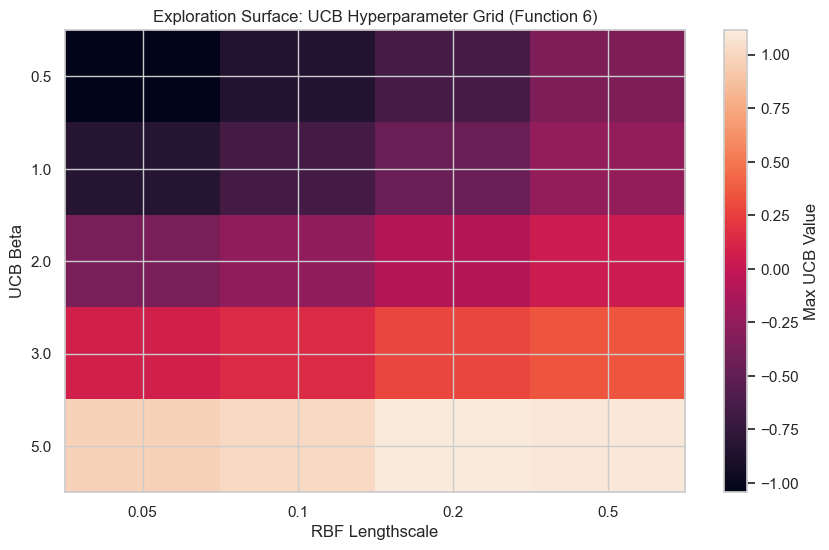

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.2
Proposed next query:
X1: 0.7274
X2: 0.3158
X3: 0.4748
X4: 0.5840
X5: 0.1838
UCB value: 1.1147


In [29]:
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):
    """
    Upper Confidence Bound acquisition function.

    Parameters
    ----------
    mu : ndarray
        Posterior mean predictions
    sigma : ndarray
        Posterior standard deviation predictions
    beta : float
        Exploration weight

    Returns
    -------
    ndarray
        UCB values
    """
    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 6)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

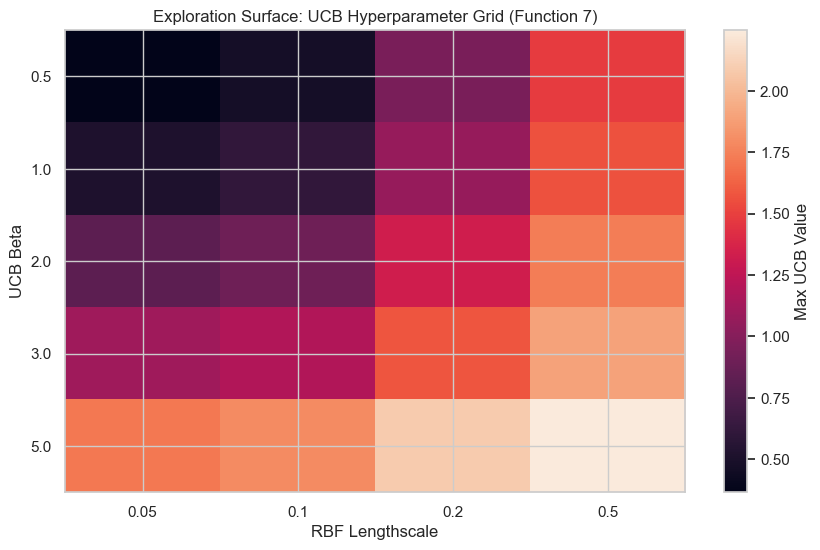

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.0002
X2: 0.1222
X3: 0.1936
X4: 0.2763
X5: 0.2437
X6: 0.8853
UCB value: 2.2467


In [30]:
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):

    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 7)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

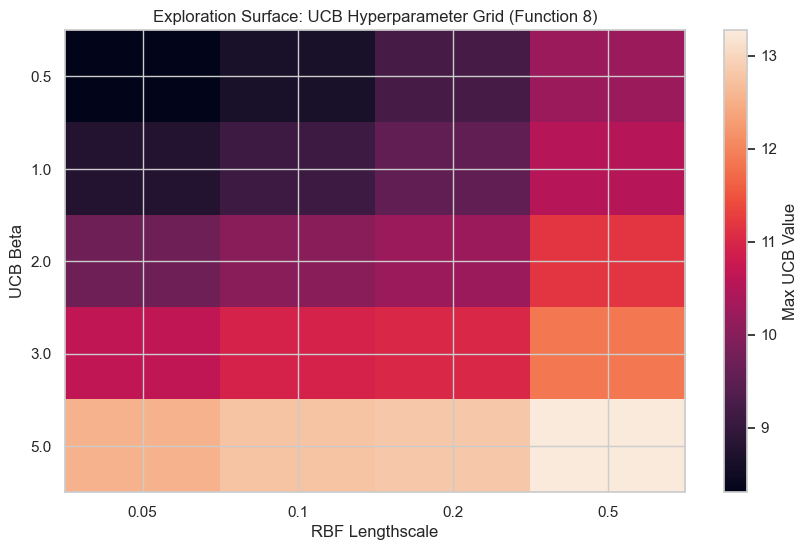

Best hyperparameter configuration (Exploration-Optimized):
Beta: 5.0
Lengthscale: 0.5
Proposed next query:
X1: 0.3379
X2: 0.1038
X3: 0.2333
X4: 0.0388
X5: 0.6364
X6: 0.2399
X7: 0.0741
X8: 0.6509
UCB value: 13.2742


In [31]:
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_obs = df[[c for c in df.columns if c.startswith("X")]].values
y_obs = df["y1"].values


# Dimensionality of the function
dim = X_obs.shape[1]

# Candidate points sampled uniformly from the domain [0, 1]^d
num_candidates = 5000
X_candidates = np.random.uniform(0, 1, size=(num_candidates, dim))

def ucb_acquisition(mu, sigma, beta):
 
    return mu + beta * sigma

# Exploration-heavy UCB betas
beta_grid = [0.5, 1.0, 2.0, 3.0, 5.0]

# Kernel lengthscales (controls smoothness / uncertainty propagation)
lengthscale_grid = [0.05, 0.1, 0.2, 0.5]

# Noise for GP numerical stability
noise_level = 1e-10


results = []

for beta, lengthscale in product(beta_grid, lengthscale_grid):

    # Define GP kernel
    kernel = RBF(length_scale=lengthscale, length_scale_bounds="fixed")

    # Fit GP model
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise_level,
        normalize_y=True
    )
    gp.fit(X_obs, y_obs)

    # Predict on candidate points
    mu, sigma = gp.predict(X_candidates, return_std=True)

    # Compute UCB
    ucb_values = ucb_acquisition(mu, sigma, beta)

    # Select best candidate under this configuration
    idx_best = np.argmax(ucb_values)
    x_best = X_candidates[idx_best]
    ucb_best = ucb_values[idx_best]

    results.append({
        "beta": beta,
        "lengthscale": lengthscale,
        "ucb_value": ucb_best,
        "x_best": x_best
    })

results_df = pd.DataFrame(results)

# Expand x vector into columns
x_cols = [f"X{i+1}" for i in range(dim)]
x_expanded = pd.DataFrame(results_df["x_best"].tolist(), columns=x_cols)

results_df = pd.concat(
    [results_df.drop(columns="x_best"), x_expanded],
    axis=1
)

results_df.sort_values("ucb_value", ascending=False, inplace=True)
results_df

pivot = results_df.pivot(
    index="beta",
    columns="lengthscale",
    values="ucb_value"
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Max UCB Value")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.xlabel("RBF Lengthscale")
plt.ylabel("UCB Beta")
plt.title("Exploration Surface: UCB Hyperparameter Grid (Function 8)")
plt.show()

best_config = results_df.iloc[0]

print("Best hyperparameter configuration (Exploration-Optimized):")
print(f"Beta: {best_config['beta']}")
print(f"Lengthscale: {best_config['lengthscale']}")
print("Proposed next query:")
for col in x_cols:
    print(f"{col}: {best_config[col]:.4f}")
print(f"UCB value: {best_config['ucb_value']:.4f}")

### Performance Metrics

In [32]:
# Disable scientific notation for pandas and numpy
pd.set_option('display.float_format', '{:.6f}'.format)
np.set_printoptions(suppress=True)

# Step 1: Store UCB predictions in a DataFrame
preds = [0.021201, 1.8786, 0.4030, 24.8417, 1945.3804, 1.1214, 2.3270, 13.3933]
actuals = [
    9.069108791316283e-223, -0.07975546223482953, -0.20496612752890705,
    -2.041748838194795, 2434.328593289806, -0.5648568336407203,
    0.7653612109103147, 9.835131961
]
functions = ['f1','f2','f3','f4','f5','f6','f7','f8']

df = pd.DataFrame({
    'Function': functions,
    'Preds': preds,
    'Actuals': actuals
})

# Step 3: Compute residuals
df['Residual_Error'] = df['Actuals'] - df['Preds']

# Compute percentage error
df['Percent_Error'] = (df['Residual_Error'] / df['Actuals']) * 100

# Round for readability
df['Percent_Error'] = df['Percent_Error'].round(3)

# Print metrics
print("\nResiduals:")
print(df[['Function', 'Residual_Error', 'Percent_Error']])


Residuals:
  Function  Residual_Error                                      Percent_Error
0       f1       -0.021201 -2337715919815634036451129993698498849654669630...
1       f2       -1.958355                                        2455.450000
2       f3       -0.607966                                         296.618000
3       f4      -26.883449                                        1316.687000
4       f5      488.948193                                          20.086000
5       f6       -1.686257                                         298.528000
6       f7       -1.561639                                        -204.039000
7       f8       -3.558168                                         -36.178000



### Residual Analysis – Post Week 2 Submission

The residuals and percentage errors provide insight into the accuracy and stability of each function (f1–f8). Below is a structured interpretation:

---

#### Overall Observations
- There is **significant variability** in both residual magnitudes and percentage errors across functions.
- Some models demonstrate **reasonable predictive performance**, while others exhibit **severe instability or scaling issues**.
- Extremely large percentage errors indicate potential **division by values close to zero**, rather than purely poor model fit.

---

#### Function-by-Function Interpretation

**f1**
- Residual: -0.021201 (very small)
- Percent Error: Extremely large negative value  
- Interpretation: Despite a negligible residual, the massive percentage error suggests the **actual value is near zero**, making the percentage metric unreliable. The model fit is likely acceptable, but **error scaling is distorted**.

**f2**
- Residual: -1.958355  
- Percent Error: 2455.45%  
- Interpretation: Indicates **poor predictive accuracy**. The model significantly deviates from observed values, likely due to **underfitting or incorrect functional form**.

**f3**
- Residual: -0.607966  
- Percent Error: 296.618%  
- Interpretation: Moderate residual but still high percentage error. Suggests **systematic deviation**, though less severe than f2. Model may need **parameter refinement**.

**f4**
- Residual: -26.883449  
- Percent Error: 1316.687%  
- Interpretation: Large residual and high percentage error indicate **substantial model misspecification**. This function performs poorly and likely requires **restructuring**.

**f5**
- Residual: 488.948193 (very large)  
- Percent Error: 20.086%  
- Interpretation: High absolute error but relatively low percentage error implies **large-scale target values**. Model may actually be **performing reasonably in relative terms**, though absolute deviations are high.

**f6**
- Residual: -1.686257  
- Percent Error: 298.528%  
- Interpretation: Similar to f3, showing **moderate absolute error but high relative error**. Indicates **inconsistent predictive accuracy**.

**f7**
- Residual: -1.561639  
- Percent Error: -204.039%  
- Interpretation: Negative percentage error suggests **directional bias** (systematic underestimation). Model may require **bias correction**.

**f8**
- Residual: -3.558168  
- Percent Error: -36.178%  
- Interpretation: Comparatively **more stable performance**. Both residual and percentage error are moderate, making this one of the **better-performing functions**.

---

#### Key Takeaways
- **Best relative performance**: f8 (most balanced error profile)
- **Acceptable with scaling caveat**: f1 (distorted by near-zero denominator)
- **Potentially viable (large-scale data)**: f5
- **Poor performers**: f2 and f4 (require major revision)
- **Moderate but iorms or additional variables** for mid-performing models (f3, f6).
```
